<a href="https://colab.research.google.com/github/nataliagdorado/Surface-EMG-Acquisition-and-Analysis./blob/main/Surface_EMG_Acquisition_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Surface EMG Acquisition and Analysis: A Biomedical Pipeline
Course: Biomedical Signals

Team members: Carlo Bottini, María Casás, Natalia García

## 1. Project Overview & Subject Profiles

### 1.1. Introduction: Objectives of the sEMG study


This project aims to familiarize our team with the acquision and analysis of biomedical signals using surface elecctromyography (sEMG).
Our mail goal is to develop a complete signal processing pipeline, from  the raw acquisition of forearm muscle signals using a BITalino device to the extraction and interpretation of relevant physiological features. We will analyze these signals in both the time and frequency domains to evaluate both physiological conditions (like fatigue) and environmental factors (like PLI) influence the recordings.

### 1.2. Experimental Setup

Recordings were captured using the BITalino, a low-cost, modular data acquisition platform. We utilized a bipolar electrode configuration on the forearm, with a reference (ground) electrode placed on the elbow to reduce noise. The experimental procedure consisted of three distinct protocols:

- **Protocol 1:** Three Maximum Voluntary Contractions (MVCs) of approximately 5 seconds each, separated by rest periods of around 10 seconds, while the BITalino device is located away from electrical sockets.

- **Protocol 2:** Three Maximum Voluntary Contractions (MVCs) of approximately 5 seconds each, separated by rest periods of around 10 seconds, while the BITalino device is located close to an electrical socket.

- **Protocol 3:** A sustained 1-minute endurance contraction to induce and observe peripheral fatigue

###1.3. Subject Metadata
Comparison of the three participants (Subject A: Male, Subject B: Female, Subject C: Female).

All the subjects will perform every protocol with their dominant hand and between each protocol and test the subjects will have a few minutes break to repose.

**Subject A**: is 21 years old, male, 172 cm tall and 64 kg, with good physical general condition. Due to physiological characteristics, when realizing the contraction the signal captured was saturated. Then to be able to analyze its signal, the subject had to perform the contraction not at its maximum.



**Subject B:** is 22 years old, female, 156cm and 68kg, with good physical condition. She plays rugby and maintains an active lifestyle.





**Subject C:** is 27 years old, female, 172cm and 68kg, with good physical condition. She maintains an active lifestyle with a consistent resistance training routine (gym-based).





##2. Environment Setup & Data Management


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.signal as signal


#for visualizing the tables
from google.colab import data_table
data_table.enable_dataframe_formatter()


###2.2. Drive Integration: Automated mounting of Google Drive.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###2.3. Data Loading

In [ ]:
path = f"/content/drive/MyDrive/Proyecto_EMG_SenalesBiomedicas/"

#we create a list for access the data with indexation
subjects= {
    "Carlo": [
        "CarloBottiniProtocol1.txt",
        "CarloBottiniProtocol2.txt",
        "CarloBottiniProtocol3.txt"
    ],
    "Maria": [
        "MariaCasasProtocol1.txt",
        "MariaCasasProtocol2.txt",
        "MariaCasasProtocol3.txt"
    ],
    "Natalia": [
        "NataliaGarciaProtocol1.txt",
        "NataliaGarciaProtocol2.txt",
        "NataliaGarciaProtocol3.txt"
    ]
}

fs=1000 # Frequency we record the data in the lab

# We generate a dictionary for the raw data
raw_data_dict={}
print("Upload raw data")
for subject, files in subjects.items():
    raw_data_dict[subject] = []
    for f in files:
        try:
            full_path= os.path.join(path, f)
            # We upload the last column, EMG in bits
            raw_signal= np.loadtxt(full_path, comments='#')[:, -1]
            raw_data_dict[subject].append(raw_signal)
            print(f"{f} upload")
        except Exception as e:
            print(f"Error in {f}: {e}")

Upload raw data
CarloBottiniProtocol1.txt upload
CarloBottiniProtocol2.txt upload
CarloBottiniProtocol3.txt upload
MariaCasasProtocol1.txt upload
MariaCasasProtocol2.txt upload
MariaCasasProtocol3.txt upload
NataliaGarciaProtocol1.txt upload
NataliaGarciaProtocol2.txt upload
NataliaGarciaProtocol3.txt upload


##3. Signal Processing


### 3.1. Digital-to-Physical Conversion: Implementation of the transfer function to convert ADC counts to Millivolts (mV) and visualization of the signals with quality assesement
We implement the transfer function to convert the ADC levels to milivolts (mV). The transfer function is:
$$EMG(mV) = \frac{\left( \frac{ADC}{2^n} - \frac{1}{2} \right) \cdot VCC}{G_{EMG}} \cdot 1000$$

Where the values are:

*   $ADC$. Value we have in the .txt
*   $2^n$. Resolution of BITalino. To normalize the value.
*   0.5. Hardware offset.
*   $VCC$. Voltage that is 3.3V
*   $G_{EMG}$. Gain of the amplifier.

We identified the hardware specifications from the OpenSignals file header, which labels the device as 'bitalino_rev' with a 10-bit quantization resolution. According to the BITalino (r)evolution datasheet [1], the sensor's amplifier gain is 1009 and the operating voltage is 3.3V. We integrated these parameters into the transfer function to convert raw ADC numbers into physical units (mV).
Additionally, a -0.5 offset was applied to compensate for the sensor's bipolar differential measurement being shifted into a unipolar range, effectively centering the resting baseline at 0 mV.

In [ ]:
def transfer_function(adc_data):
    n_bits= 10
    vcc=3.3
    gain=1009

    # BITalino (r)evolution: ((ADC / 2^n)- 0.5) *VCC /Gain
    # in this case we calculate for mv
    emg_mv= ((adc_data / (2**n_bits))- 0.5) *vcc /gain * 1000

    return emg_mv



Now we have to replace the data recorded by the data in mV in order to work with them, creating a new dictionary and appliying the transfer function

In [ ]:
#for access with keys
data_dict= {}
for subject,signals in raw_data_dict.items():
    data_dict[subject]= [transfer_function(s) for s in signals]

And we visualize the three protocols for each subject

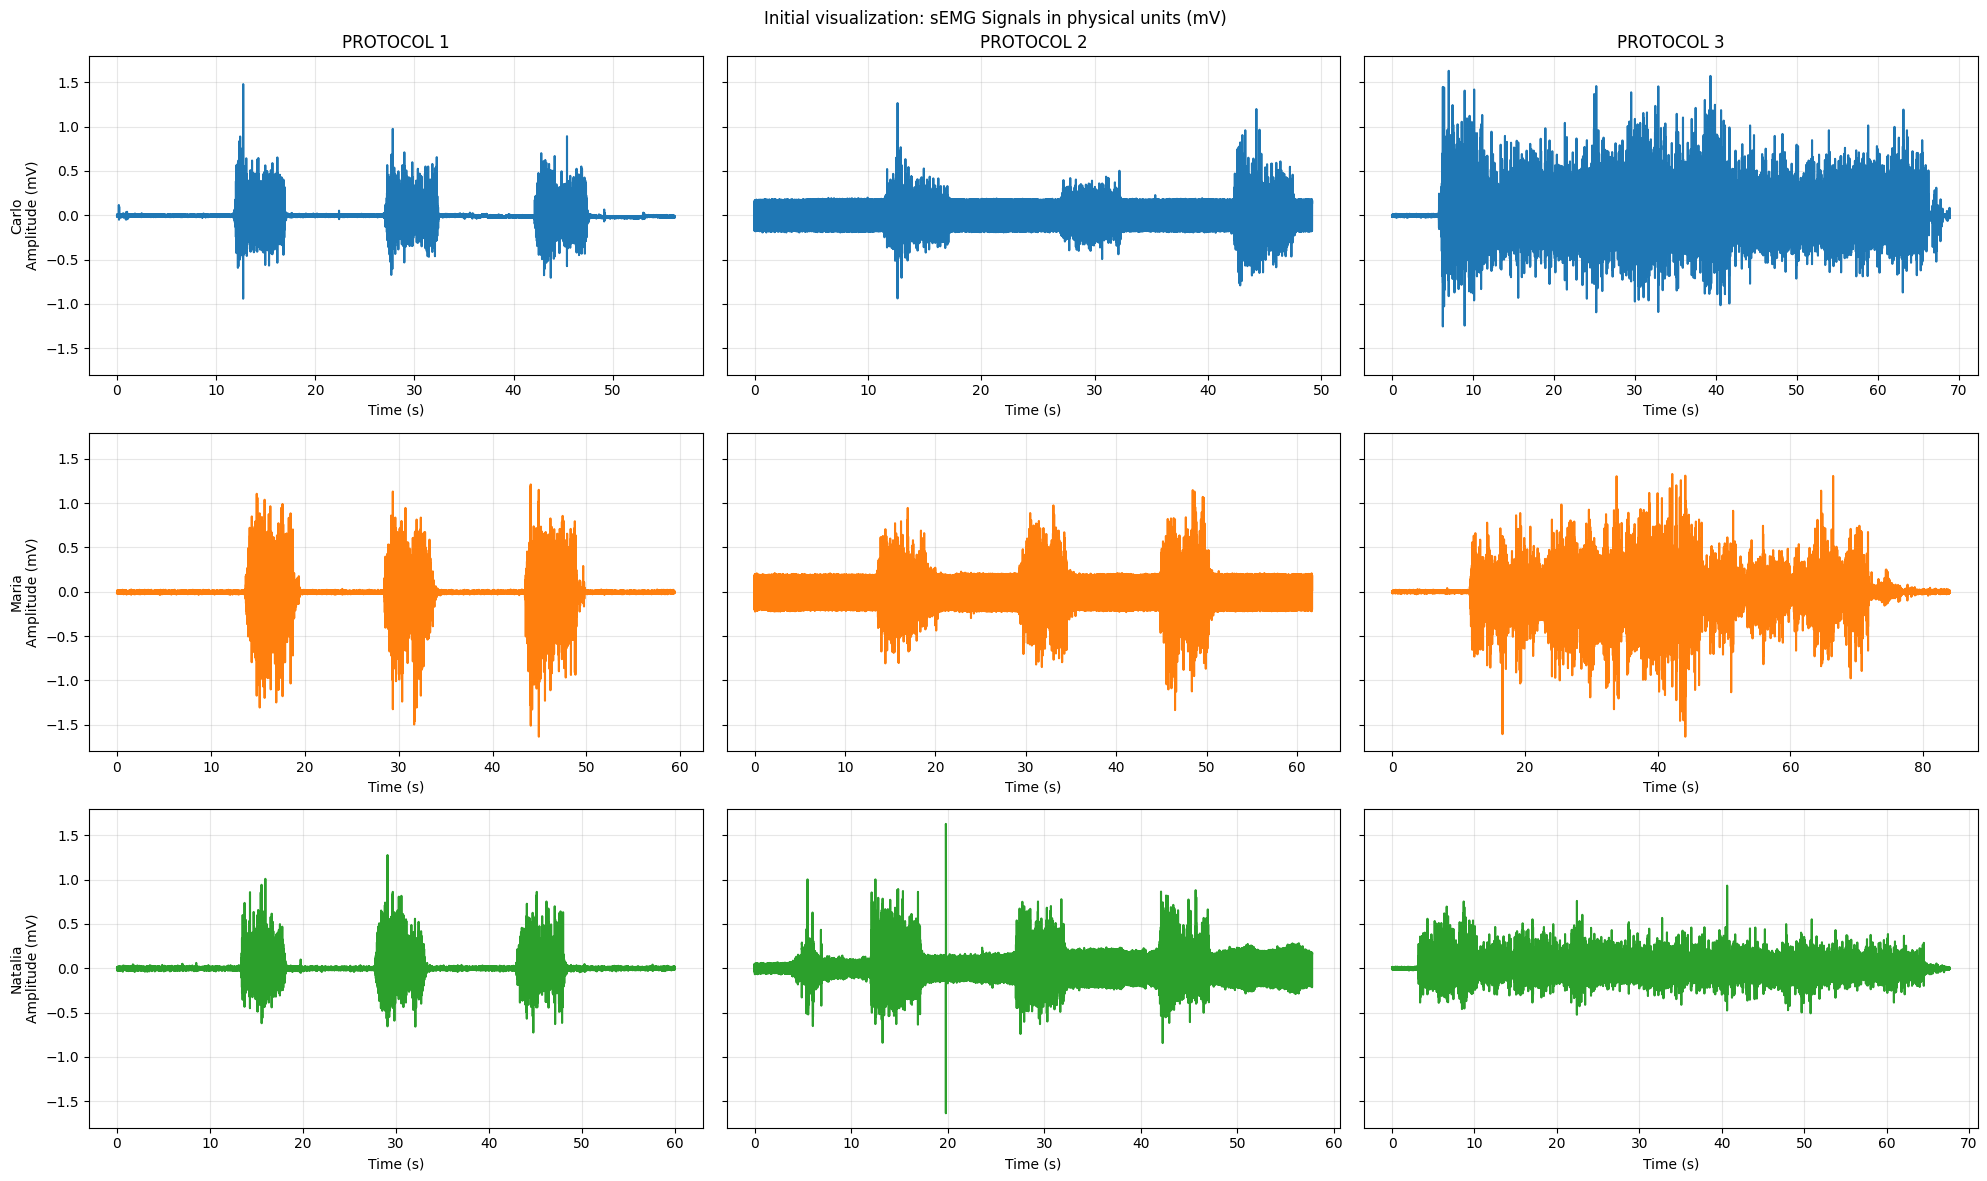

In [ ]:
fig, axes = plt.subplots(3, 3,figsize=(20, 12), sharey=True)
colors= ['#1f77b4', '#ff7f0e', '#2ca02c']
subjects_names= list(data_dict.keys())

for row,subject in enumerate(subjects_names):
    for col in range(3):
        ax= axes[row, col]
        signal_mv= data_dict[subject][col]
        time= np.arange(len(signal_mv)) / fs

        ax.plot(time, signal_mv, color=colors[row])

        if row== 0:
            ax.set_title(f"PROTOCOL {col+1}")
        if col== 0:
            ax.set_ylabel(f"{subject}\nAmplitude (mV)")
        ax.set_xlabel("Time (s)")
        ax.grid(alpha=0.3)

plt.suptitle("Initial visualization: sEMG Signals in physical units (mV)")
plt.tight_layout()
plt.show()

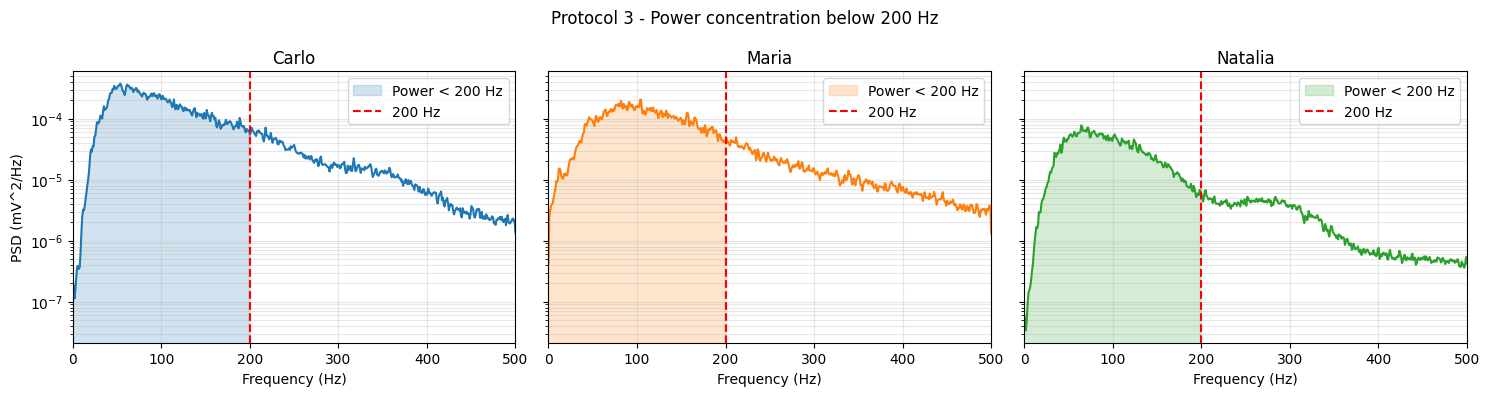

In [ ]:
# PSD of Protocol 3 - verified power concentration below 200 Hz (slide 11 EMG Lecture)
fig, axes= plt.subplots(1,3, figsize=(15, 4), sharey=True)

for i, subject in enumerate(subjects_names):
    sig_p3= data_dict[subject][2]
    f, psd= signal.welch(sig_p3, fs=fs, nperseg=1024)

    ax= axes[i]
    ax.semilogy(f, psd, color=colors[i])
    ax.fill_between(f, psd, where=(f <= 200), alpha=0.2, color=colors[i], label='Power < 200 Hz')
    ax.axvline(200, color='red', linestyle='--', label='200 Hz')
    ax.set_title(subject)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim(0, 500)
    ax.grid(alpha=0.3, which='both') #small lines and default lines that have numbers
    ax.legend()

axes[0].set_ylabel('PSD (mV^2/Hz)')
plt.suptitle('Protocol 3 - Power concentration below 200 Hz')
plt.tight_layout()
plt.show()

**General Observation: Time Delay**

The time axis varies slightly across recordings because these are raw data files. We record approximately 10 seconds of resting baseline before starting the actual muscle contraction to ensure the system is stable

**Observation by subject time and frequency**

*Subject 1 (Blue - Carlo)*
* Protocol 1 (MVC). Amplitude: Bursts are approx 0.5 - 1.5 mV (Pass: within 0.05 - 5 mV range). Baseline: Visually low, suggests minor external noise.
* Protocol 2 (PLI Noise). Amplitude: Bursts visible but contaminated. Baseline: Fails the < 5 µV requirement for not noise; shows a thick band of Power Line Interference (PLI) from the electrical socket.
* Protocol 3 (Endurance). Amplitude: Sustained high amplitude approx 1.5 mV.Bandwidth: Visually captures typical sEMG high-frequency content.

*Subject 2 (Orange - Maria)*
* Protocol 1 (MVC). Amplitude: Clear bursts reaching approx 1.2 mV (Pass: within 0.05 - 5 mV range). Baseline: Shows minimal noise.
* Protocol 2 (PLI Noise). Amplitude: Bursts visible but masked by high noise floor. Baseline: Significant PLI interference from the electrical socket; fails the < 5 µV requirement.
* Protocol 3 (Endurance). Amplitude: Sustained activity at approx 1.0 mV. Bandwidth: Power appears concentrated below 200 Hz as expected for sEMG signals.

*Subject 3 (Green - Natalia)*
* Protocol 1 (MVC). Amplitude: Clear activation bursts approx 1.0 mV (Pass: within 0.05 - 5 mV range). Baseline: Shows small
* Protocol 2 (PLI Noise). Amplitude: Bursts are clear, but one large motion artifact is visible at approx 20s. Baseline: Fails < 5 µV requirement; heavily contaminated by environmental noise.
* Protocol 3 (Endurance). Amplitude: Activity approx 0.7 mV. Bandwidth: High-frequency limits affected by tissue thickness and skin impedance.




The PSD plots confirm that the majority of the signal power in Protocol 3 is concentrated below 200 Hz for all three subjects. This is consistent with the known frequency content of sEMG signals, where most myoelectric activity falls within the 20-200 Hz range. The sharp drop in power beyond 200 Hz justifies using this as a reference bandwidth for signal characterization.

In [ ]:
quality_data = {
    'Feature': [
        'Burst Amplitude',
        'Baseline Noise',
        'Low-Freq Artifacts',
        'PLI Interference'
    ],
    'Lecture EMG Standard Values': [
        '0.05-5 mV',
        '< 5 μV',
        '1-50Hz (Cables/Motion)',
        '50 Hz (Power line)'
    ],
    'Observed Result (All Subjects)': [
        '≈ 0.5 - 1.5 mV',
        '≈ 20 - 150 μV (especially in P2)',
        'Visible baseline "wandering" in P1 and P3',
        'Heavy "thick" baseline in all Protocol 2 files'
    ],
    'Status': [
        'PASS',
        'FAIL',
        'TO REVISE',
        'TO REVISE'
    ]
}

df_quality=pd.DataFrame(quality_data)
df_quality

,Feature,Lecture EMG Standard Values,Observed Result (All Subjects),Status
0,Burst Amplitude,0.05-5 mV,≈ 0.5 - 1.5 mV,PASS
1,Baseline Noise,< 5 μV,≈ 20 - 150 μV (especially in P2),FAIL
2,Low-Freq Artifacts,1-50Hz (Cables/Motion),"Visible baseline ""wandering"" in P1 and P3",TO REVISE
3,PLI Interference,50 Hz (Power line),"Heavy ""thick"" baseline in all Protocol 2 files",TO REVISE


Proposed strategies based on slide 16 of the EMG Lecture:

In [ ]:
data = {
    'Filter Type': ['High-Pass (HP)', 'Low-Pass (LP)', 'Notch Filter'],
    'Target Noise': ['Cable/Motion', 'Electronics/Aliasing', 'Power Line (PLI)'],
    'Specification': ['Butterworth 4th (20 Hz)', 'Butterworth 4th (450 Hz)', 'Recursive IIR (50 Hz)'],
    'Justification': ['Removes artifacts < 20 Hz', 'Limits bandwidth to sEMG range', 'Important for Protocol 2']
}
df = pd.DataFrame(data)
df

,Filter Type,Target Noise,Specification,Justification
0,High-Pass (HP),Cable/Motion,Butterworth 4th (20 Hz),Removes artifacts < 20 Hz
1,Low-Pass (LP),Electronics/Aliasing,Butterworth 4th (450 Hz),Limits bandwidth to sEMG range
2,Notch Filter,Power Line (PLI),Recursive IIR (50 Hz),Important for Protocol 2



### 3.2. Preprocessing (Noise Attenuation): Elimination of non-muscular artifacts using standardized filter

Before extracting any features, the raw signal must be cleaned. The goal of this preprocessing stage is to attenuate frequency components outside the  frequency band of sEMG signals strictly preserving the signal components associated with myoelectrical activity. We apply a sequential filtering strategy based on the specifications defined in our quality assessment.



#### 3.2.1. Band-Pass Filtering
We implement a 4th-order Butterworth Band-Pass filter with a passband of 20 Hz to 450 Hz. This filter is a combination of a High-Pass and a Low-Pass filter:
* **High-Pass Component (20 Hz):** Removes out-of-band low-frequency noise, specifically targeting cable motion artifacts (1-50 Hz) and electrode motion artifacts (< 20 Hz).
* **Low-Pass Component (450 Hz):** Limits the bandwidth to the physiological range of sEMG signals (typically < 500 Hz). The cuttof is chosen for Nyquist critetion.

We use the `scipy.signal.filtfilt` function to apply the filter both forwards and backwards, ensuring zero phase shift so the temporal alignment of the muscle contractions remains intact.







In [ ]:
#Implementation of the Band-Pass Filter

def apply_bandpass_filter(data, fs=1000, lowcut=20.0, highcut=450.0, order=4):
    nyq= 0.5*fs
    low= lowcut /nyq
    high= highcut /nyq

    #Generate filter coefficients
    b, a=signal.butter(order, [low, high], btype='band')

    #Apply filter forwards and backwards to prevent phase shift
    filtered_data= signal.filtfilt(b, a, data)
    return filtered_data

####3.2.2. Notch Filtering: 50 Hz recursive IIR filter designed to eliminate Power Line Interference (PLI) (Protocol 2).



To address the severe baseline contamination observed in Protocol 2, we implement a recursive IIR Notch filter. This filter is used specifically to target Power Line Interference (PLI) at the 50 Hz fundamental frequency.

*Note on limitations:* Because PLI (50 Hz) falls squarely inside the most powerful part of the EMG spectrum (< 200 Hz), applying this filter may cause some attenuation of the signal of interest. However, it is a necessary compromise to clean the thick noise baseline and allow for accurate amplitude parametrization.


In [ ]:
# Implementation of the Notch Filter
# q is quality factor. q=f0/bw

def apply_notch_filter(data, fs=1000, f0=50.0, Q=30.0):
    # Generate filter coefficients
    b,a= signal.iirnotch(f0, Q, fs)

    # Apply filter forwards and backwards
    filtered_data= signal.filtfilt(b, a, data)
    return filtered_data

Now we process the signal with the filters

In [ ]:
# Create a new dictionary to store the filtered signals
filtered_data_dict={}

print("Applying preprocessing (Band-Pass + Notch)")
for subject, signals in data_dict.items(): # data_dict contains the mV signals from 3.1
    filtered_data_dict[subject] = []

    for sig in signals:
        # Band-Pass filter to remove motion and high-freq noise
        bp_sig = apply_bandpass_filter(sig, fs=fs)

        # Notch filter to eliminate 50 Hz PLI
        clean_sig= apply_notch_filter(bp_sig, fs=fs)

        filtered_data_dict[subject].append(clean_sig)

print("Filtering complete for all subjects and protocols.")

Applying preprocessing (Band-Pass + Notch)
Filtering complete for all subjects and protocols.


While the preprocessing pipeline was applied to all three protocols for consistency, we present the visual validation for Protocol 2 as it contained the highest levels of Power Line Interference (PLI), best demonstrating the filters efficiency.

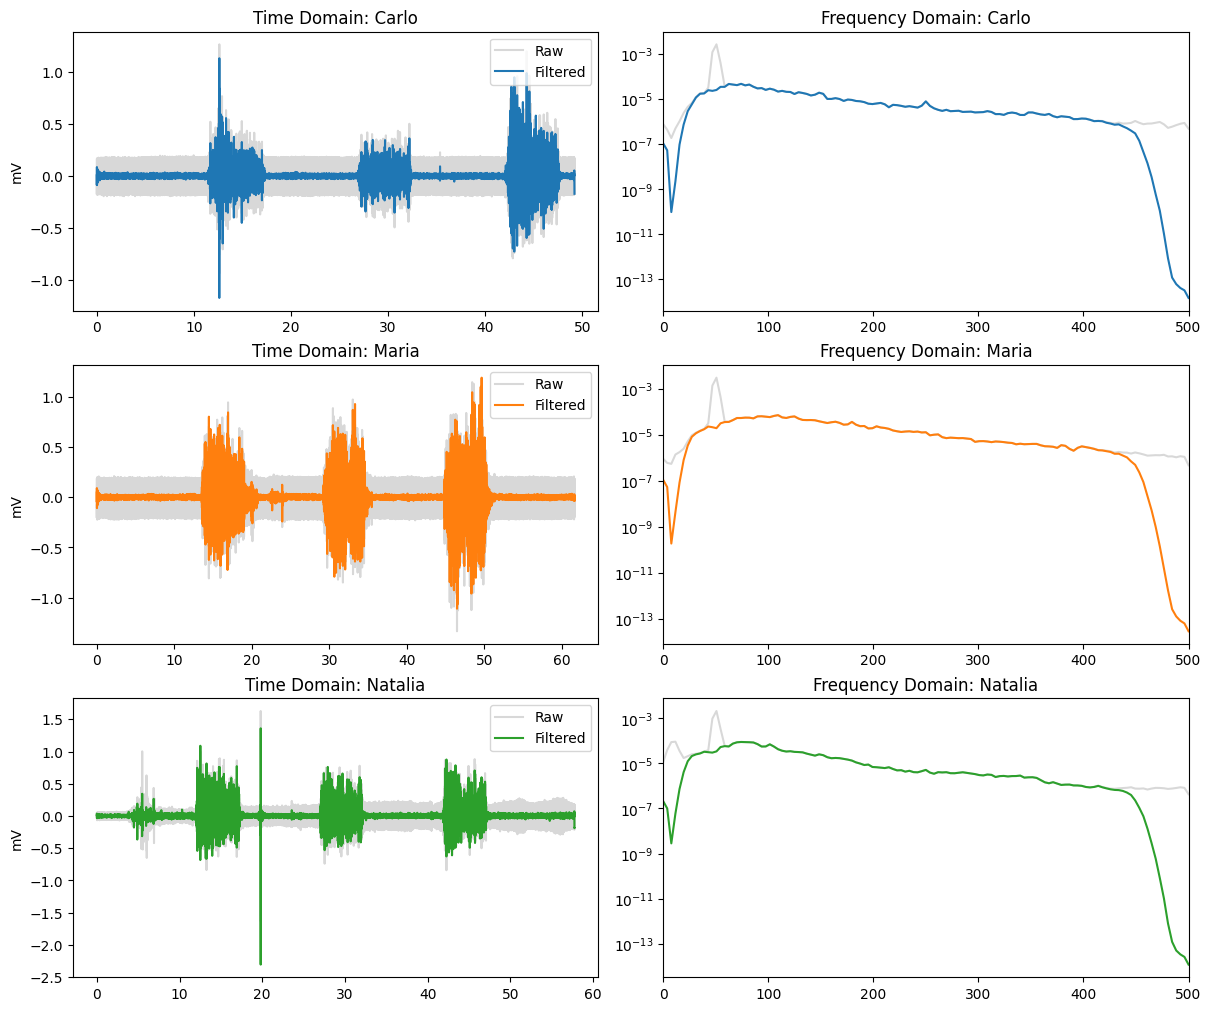

In [ ]:
# Visualization: Demonstrating the effect of the filters
# We will plot the raw vs filtered signal for Protocol 2 (which had heavy PLI) for the three subjects
# So we can see the difference and the application of these filters
p_idx=1

# subplot
fig, axes= plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)

for i, nombre in enumerate(subjects_names):
    raw= data_dict[nombre][p_idx]
    filtrada= filtered_data_dict[nombre][p_idx]
    t= np.arange(len(raw)) / fs

    axes[i, 0].plot(t, raw, color='gray', alpha=0.3, label='Raw')
    axes[i, 0].plot(t, filtrada, color=colors[i], label='Filtered')
    axes[i, 0].set_title(f"Time Domain: {nombre}")
    axes[i, 0].set_ylabel("mV")
    axes[i, 0].legend(loc='upper right')

    # psd
    f,psd_raw= signal.welch(raw, fs)
    f,psd_filt= signal.welch(filtrada, fs)

    axes[i, 1].semilogy(f, psd_raw, color='gray', alpha=0.3)
    axes[i, 1].semilogy(f, psd_filt, color=colors[i])
    axes[i, 1].set_title(f"Frequency Domain: {nombre}")
    axes[i, 1].set_xlim([0, 500]) # we only show until nyquist

plt.show()

We can clearly observe the successful implementation of the 4th-order Butterworth band-pass filter and the recursive IIR Notch filter. The reduction of the Power Line Interference by the deep "notch" at 50 Hz in all Filtered frequency spectra.
Natalia’s signal shows a high-amplitude spike at t=20s caused by cable motion. Our filters didn't remove it because its frequencies overlap with the muscle signal (20-450 Hz), making it impossible to isolate with standard methods

#### Excursus 1: Testing one by one the filters
In order to know if each filter works by themselves, we show for Subject 1 (Carlo) the comparation beteen the raw signal, the signal with the bandpass filter and the signal with BP and notch.

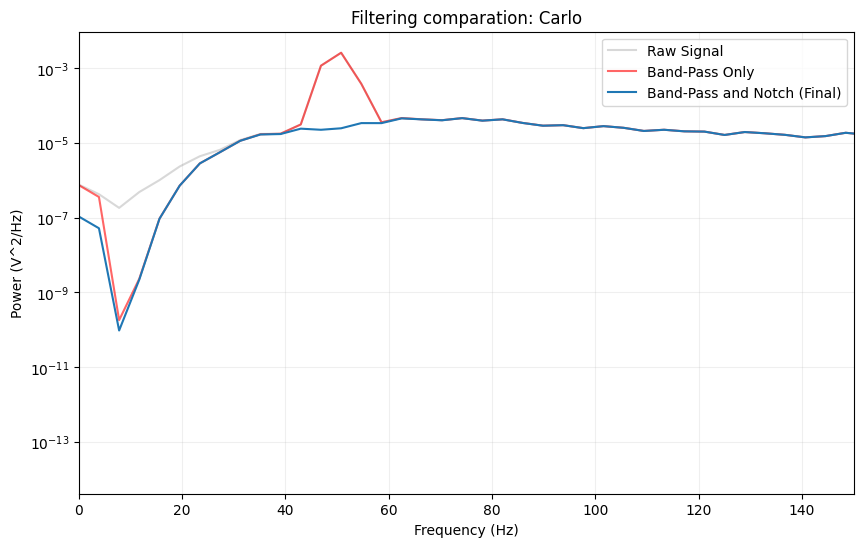

In [ ]:
sujeto_test= "Carlo"
p_idx= 1
raw_sig= data_dict[sujeto_test][p_idx]

#ONLY BANDPASS
solo_bp=apply_bandpass_filter(raw_sig, fs=fs)

#notch over the bandpass
bp_notch=apply_notch_filter(solo_bp, fs=fs)

plt.figure(figsize=(10, 6))

# We calculate the PSD for better visualization using welch's function
f, p_raw= signal.welch(raw_sig, fs)
f, p_bp= signal.welch(solo_bp, fs)
f, p_total= signal.welch(bp_notch, fs)

plt.semilogy(f,p_raw, color='gray', alpha=0.3, label='Raw Signal')
plt.semilogy(f,p_bp, color='red', alpha=0.6, label='Band-Pass Only ')
plt.semilogy(f,p_total, color=colors[0], label='Band-Pass and Notch (Final)')

plt.title(f"Filtering comparation: {sujeto_test}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (V^2/Hz)")
plt.xlim([0, 150]) #We're looking fot the 50Hz peak
plt.legend()
plt.grid(alpha=0.2, which='both')
plt.show()

The plot shows each filtering stage. The raw signal (gray) has low-frequency noise. The Band-pass filter (red) removes this noise but keeps the 50 Hz spike. The Notch filter (blue) removes that spike. Both are needed to get a clean baseline for the spectral analysis.

#### Excursus 2: Trying to remove Natalia's motion artifact


In Natalia’s Protocol 2 plot, we can clearly see a isolated peak at approximately second 20. This is not muscle activity, but a motion artifact. These artifacts are usually caused by a  pull on the cables. This noise is problematic because its high amplitude can completely distort our later calculations of Total Power and frequency.

Even after applying a 4th-order Butterworth Band-Pass (20-450 Hz) and a Notch filter (50 Hz), the motion spike in Natalia's signal remained intact. This happens because a sharp transient artifact behaves like a Dirac impulse.



We explored two complementary strategies to deal with this artifact, both built exclusively on tools covered in the course (statistical thresholding, envelope detection, and segment replacement). The first is a simple sample-level approach; the second is a more robust window-level approach. We compare them quantitatively and adopt the better one for the rest of the analysis.






**Method 1 - Statistical Sample Thresholding**



The simplest possible idea: identify the individual samples whose amplitude is well outside the normal noise range, and replace them with realistic noise drawn from a clean rest period.

Method 1: Threshold = 0.7105 mV
Method 1: 26 samples replaced (0.05% of signal)


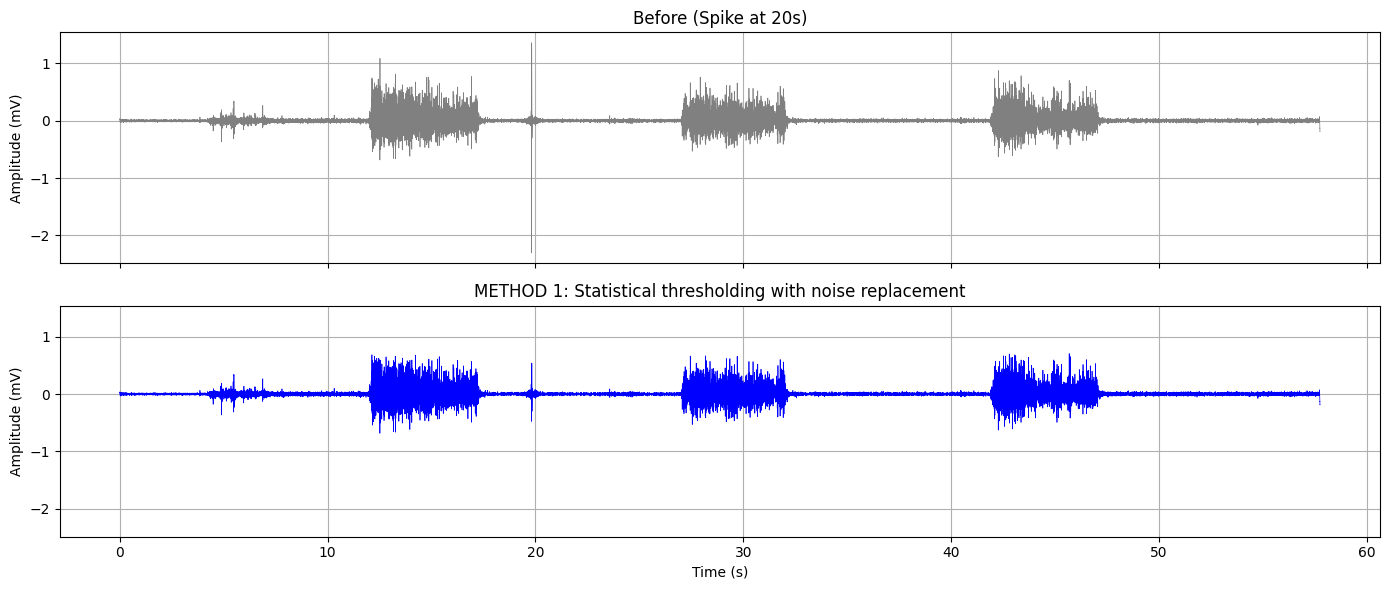

In [ ]:
# METHOD 1: Statistical Thresholding with Noise Replacement
# Identify samples whose amplitude is far outside the normal noise range, and replace them with realistic noise from a clean rest period.
# The threshold is computed from a CLEAN segment so that neither the artifact nor the EMG bursts inflate it.

# Start from the linearly-filtered signal (BP + Notch from section 3.2)
sig_original= filtered_data_dict['Natalia'][1].copy()
fs= 1000
time_arr= np.arange(len(sig_original))/ fs

# Estimate noise statistics from a clean rest window at the end of the signal
# We use the last 5 seconds
rest_window= sig_original[-int(5*fs):]
noise_std= np.std(rest_window)
noise_mean= np.mean(rest_window)

# Define the outlier threshold
# We set the threshold, the artifact's extreme tip is detected
threshold=45* noise_std

# Identify outlier samples
# Boolean array: True where the signal exceeds the threshold
outlier_mask= np.abs(sig_original- noise_mean) > threshold

# Replace each outlier with a random sample from the rest window
# Using random rest samples (instead of zero or the mean) preserves the natural texture of the noise floor and avoids creating a flat dead zone
sig_method1= sig_original.copy()
n_outliers= np.sum(outlier_mask)
if n_outliers > 0:
    replacement_noise =np.random.choice(rest_window, size=n_outliers, replace=True)
    sig_method1[outlier_mask] =replacement_noise

print(f"Method 1: Threshold = {threshold:.4f} mV")
print(f"Method 1: {n_outliers} samples replaced "
      f"({100*n_outliers/len(sig_original):.2f}% of signal)")

fig, (ax1, ax2)= plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)
ax1.plot(time_arr, sig_original, color='gray', lw=0.5)
ax1.set_title("Before (Spike at 20s)")
ax1.set_ylabel("Amplitude (mV)")
ax1.grid()

ax2.plot(time_arr, sig_method1, color='blue', lw=0.5)
ax2.set_title("METHOD 1: Statistical thresholding with noise replacement")
ax2.set_ylabel("Amplitude (mV)")
ax2.set_xlabel("Time (s)")
ax2.grid()
plt.tight_layout()
plt.show()


The threshold is computed from a clean reference (rest period), so it correctly distinguishes between EMG burst amplitude (3-5σ of rest noise) and artifact amplitude (>6σ).

And the replacement preserves the visual continuity of the noise floor.


**Limitation:** It only catches the very tip of the spike. The artifact's "shoulders" (the surrounding low-frequency wobble) still pass.

**Method 2 — Adaptive Time-Localized Excision**

Detect the artifact window automatically, then replace it with a noise sample that matches the surrounding statistics.


The detection is done in three steps:

1. Build a smooth envelope of the rectified signal (50 ms moving average). The envelope tracks the local intensity of the signal.
2. Estimate the "normal" maximum envelope value as the 99th percentile of the envelope. By construction, everything above this value is either the artifact itself or the very top of an MVC burst, but since the artifact is the global maximum, it is the dominant contributor.
3. Walk left and right from the artifact peak while the envelope stays above this normal-maximum level, and add a small safety margin on each side.


Method 2: Artifact peak detected at t = 19.82 s
Method 2: Artifact window auto-detected: 19.74s to 19.90s (duration = 155 ms)


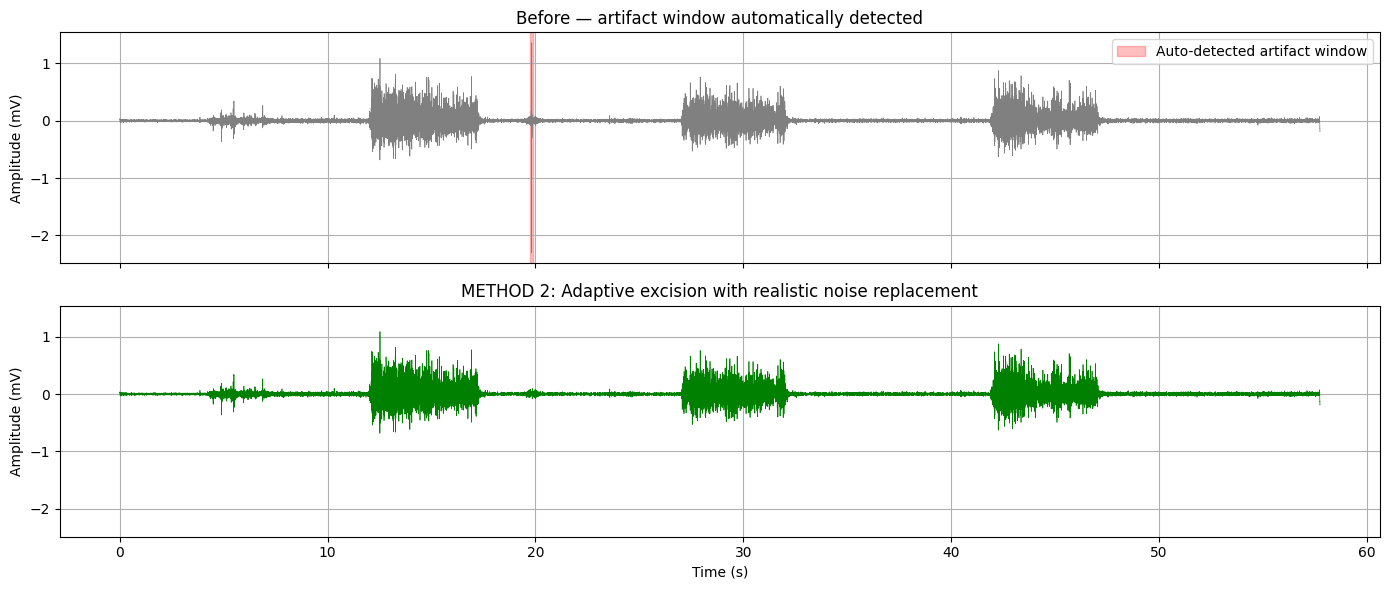

In [ ]:
# METHOD 2: Adaptive Excision with Matched Noise Replacement
# Automatically locate the artifact in time, then replace the entire affected window with realistic noise sampled from a clean rest period.
# The window is detected from the data itself, without hardcoding any time limit

sig_original= filtered_data_dict['Natalia'][1].copy()
fs =1000
time_arr= np.arange(len(sig_original)) / fs

# Building a smooth envelope of the absolute signal
# The envelope tracks the local intensity of the signal
# A short 50 ms moving average is enough to smooth out the fast EMG oscillations while preserving the artifact's broad shape
abs_sig =np.abs(sig_original)
window_ms =50
window_samples= int((window_ms / 1000) * fs)
smooth_envelope= np.convolve(abs_sig, np.ones(window_samples)/window_samples, mode='same')

# Estimate the "normal" maximum envelope value
# We take the 99th percentile of the envelope. The 1% above this is, almost by definition, the artifact itself, so the percentile represents the maximum envelope reached by genuine EMG bursts
normal_max=np.percentile(smooth_envelope, 99)

# Finding the artifact peak
# The single sample with the largest absolute amplitude is the spike center.
peak_idx =np.argmax(np.abs(sig_original))
peak_time =peak_idx /fs
print(f"Method 2: Artifact peak detected at t = {peak_time:.2f} s")

# Walk outward from the peak to find the artifact's edges
# We extend the window left and right while the envelope is still above the normal MVC level. As soon as it drops back to physiological values we mark that as the artifact's boundary
left_idx = peak_idx
while left_idx >0 and smooth_envelope[left_idx] > normal_max:
    left_idx -=1
right_idx = peak_idx
while right_idx <len(sig_original) -1 and smooth_envelope[right_idx] > normal_max:
    right_idx +=1

# Add a small 50 ms safety margin on each side to make sure we capture the whole artifact, including its fading edges.
margin= int(0.05*fs)
left_idx= max(0, left_idx- margin)
right_idx= min(len(sig_original), right_idx+ margin)

artifact_duration =(right_idx - left_idx)/ fs
print(f"Method 2: Artifact window auto-detected: "
      f"{left_idx/fs:.2f}s to {right_idx/fs:.2f}s "
      f"(duration = {artifact_duration*1000:.0f} ms)")

# Replace the detected window with matched statistics noise
# We sample (with replacement) from the clean rest window. The replacement should be indistinguishable from a natural rest period
rest_window =sig_original[:int(8 * fs)]
sig_method2 =sig_original.copy()
n_replace =right_idx - left_idx
replacement =np.random.choice(rest_window, size=n_replace, replace=True)
sig_method2[left_idx:right_idx] = replacement

fig, (ax1, ax2) =plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)
ax1.plot(time_arr,sig_original, color='gray', lw=0.5)
ax1.axvspan(left_idx/fs,right_idx/fs, alpha=0.25, color='red',
            label='Auto-detected artifact window')
ax1.set_title("Before — artifact window automatically detected")
ax1.set_ylabel("Amplitude (mV)")
ax1.legend(loc='upper right')
ax1.grid()

ax2.plot(time_arr,sig_method2, color='green', lw=0.5)
ax2.set_title("METHOD 2: Adaptive excision with realistic noise replacement")
ax2.set_ylabel("Amplitude (mV)")
ax2.set_xlabel("Time (s)")
ax2.grid()
plt.tight_layout()
plt.show()

The window is detected automatically from the data (no hardcoded 19s to 21s).

The replacement looks indistinguishable from natural rest periods.

**Limitation:**  throws away 1s of data. If a real contraction happened to coincide with the artifact, we would lose it. In Natalia's protocol 2 the artifact is during a rest period, so this works perfectly.

**PLOTS FOR COMPARING BOTH METHOD**

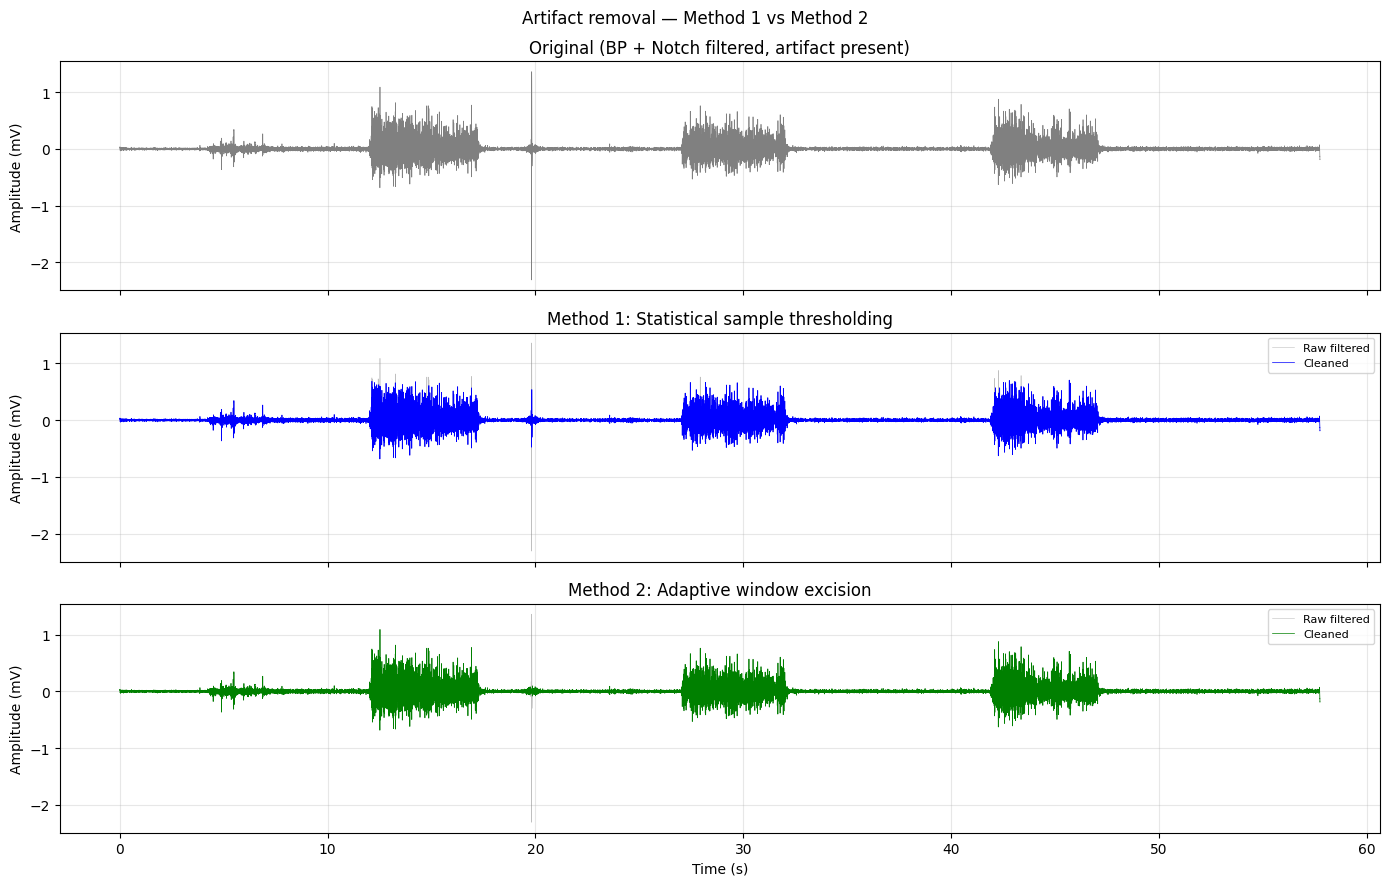

Quantitative comparison:
Signal                                RMS rest    RMS MVC   Peak artifact
Original (artifact present)            0.03131    0.15281          2.3079
Method 1 (sample threshold)            0.03131    0.15017          0.5391
Method 2 (window excision)             0.03131    0.15281          0.0948

 Method 2 saved to filtered_data_dict['Natalia'][1]


In [ ]:
# COMPARISON: All four methods
fig, axes=plt.subplots(3, 1, figsize=(14, 9), sharex=True, sharey=True)

axes[0].plot(time_arr, sig_original, color='gray', lw=0.5)
axes[0].set_title("Original (BP + Notch filtered, artifact present)")
axes[0].set_ylabel("Amplitude (mV)")
axes[0].grid(alpha=0.3)

axes[1].plot(time_arr, sig_original, color='gray', lw=0.4, alpha=0.5, label='Raw filtered')
axes[1].plot(time_arr, sig_method1, color='blue', lw=0.5, label='Cleaned')
axes[1].set_title("Method 1: Statistical sample thresholding")
axes[1].set_ylabel("Amplitude (mV)")
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(alpha=0.3)

axes[2].plot(time_arr, sig_original, color='gray', lw=0.4, alpha=0.5, label='Raw filtered')
axes[2].plot(time_arr, sig_method2, color='green', lw=0.5, label='Cleaned')
axes[2].set_title("Method 2: Adaptive window excision")
axes[2].set_ylabel("Amplitude (mV)")
axes[2].set_xlabel("Time (s)")
axes[2].legend(loc='upper right', fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle("Artifact removal — Method 1 vs Method 2")
plt.tight_layout()
plt.show()


# Quantitative comparison.
# - RMS over a clean rest baseline (should be small and similar across methods → tells us the noise floor was preserved).
# - RMS over a clean MVC away from the artifact (should be preserved → tells us we did not damage the EMG).
# - Peak amplitude in the artifact window (should drop to ~MVC level → tells us the spike was successfully suppressed).
def rms(x):
    return np.sqrt(np.mean(x**2))

rest_idx= slice(int(0*fs),  int(8*fs))# clean rest baseline
mvc_idx= slice(int(13*fs), int(18*fs))# an MVC away from the artifact
artifact_window= slice(int(19*fs), int(21*fs))# artifact region

print("Quantitative comparison:")
print(f"{'Signal':<35} {'RMS rest':>10} {'RMS MVC':>10} {'Peak artifact':>15}")
for label, sig in [
    ('Original (artifact present)', sig_original),
    ('Method 1 (sample threshold)', sig_method1),
    ('Method 2 (window excision)',  sig_method2),
]:
    print(f"{label:<35} "
          f"{rms(sig[rest_idx]):>10.5f} "
          f"{rms(sig[mvc_idx]):>10.5f} "
          f"{np.max(np.abs(sig[artifact_window])):>15.4f}")


# Save the chosen method (Method 2) as the cleaned signal
filtered_data_dict['Natalia'][1] = sig_method2
print("\n Method 2 saved to filtered_data_dict['Natalia'][1]")



**Summary**

**Method 1 :** Statistical thresholding identifies samples that exceed a noise-derived bound and replaces them with realistic noise drawn from a clean rest period. The threshold is computed from the last 5 seconds of the recording (a clean rest window), so it is not contaminated by either the artifact or the EMG bursts. The method targets only the most extreme outliers, typically the very tip of the artifact, while leaving the EMG completely untouched. Its main limitation is that it only catches a few samples around the peak; the wider "shoulders" of the transient still pass through.

**Method 2 :** Adaptive excision automatically locates the artifact by smoothing the rectified signal and comparing it to the 99th percentile of normal envelope amplitude. Once the boundaries of the artifact are detected, the entire window is replaced by realistic noise sampled from a clean rest period. This produces a visually seamless result because the replacement statistics match the surrounding noise floor exactly. The main trade-off is that it is destructive: roughly one second of data is discarded. In our case this is acceptable because the artifact occurred during a rest interval, not during an MVC.

**Final discussion and choice:**

Both methods successfully reduce the motion artifact, but with different trade-offs.


Method 1 operates sample-by-sample with a fixed threshold and only catches the spike's extreme tip; the lower-amplitude "shoulders" of the transient still pass through.


Method 2 detects the entire contaminated window from the data itself and replaces it with realistic noise drawn from a clean rest segment.


For the downstream analysis (RMS extraction, SNR estimation, spectral characterization) we adopt Method 2 as the cleaned version of Natalia's Protocol 2 signal. It removes the artifact more completely than Method 1, the artifact happens to fall in a rest interval (so no real EMG is lost), and it relies only on tools covered in the course: rectification, envelope smoothing, statistical thresholding, and segment replacement.


### 4. Temporal Analysis: MVC & Muscle Activation (Protocol 1)



The goal of this section is to detect each Maximum Voluntary Contraction (MVC) automatically and to quantify its amplitude. To do this we first need to transform the cleaned (filtered) signal into a smooth amplitude envelope, which makes the muscle "ON/OFF" transitions easy to detect by
thresholding.

#### 4.1. Envelope Extraction and Automated MVC Detection: Implementing a threshold-based algorithm to detect Onset and Offset of the 3 MVCs ($Mean_{noise} + k \cdot \sigma_{noise}$)


The final step of the processing pipeline transforms the filtered signal into a smooth amplitude envelope and uses it to automatically detect the onset and offset of each contraction.

First, we apply full-wave rectification by taking the absolute value of the signal. The raw EMG oscillates around zero, a direct average would cancel out, so rectification flips all negative values to positive before smoothing.

Then we apply a 250 ms RMS window, which squares the samples, averages them over the window, and takes the square root. This produces a smooth envelope that tracks muscle activation over time.

This envelope is then fed into a threshold-based detector: the threshold is computed as Mean + 6σ of the first 8 seconds of resting baseline, which adapts automatically to each subject's noise floor. Any event exceeding this threshold for more than 1.5 seconds is classified as an MVC.

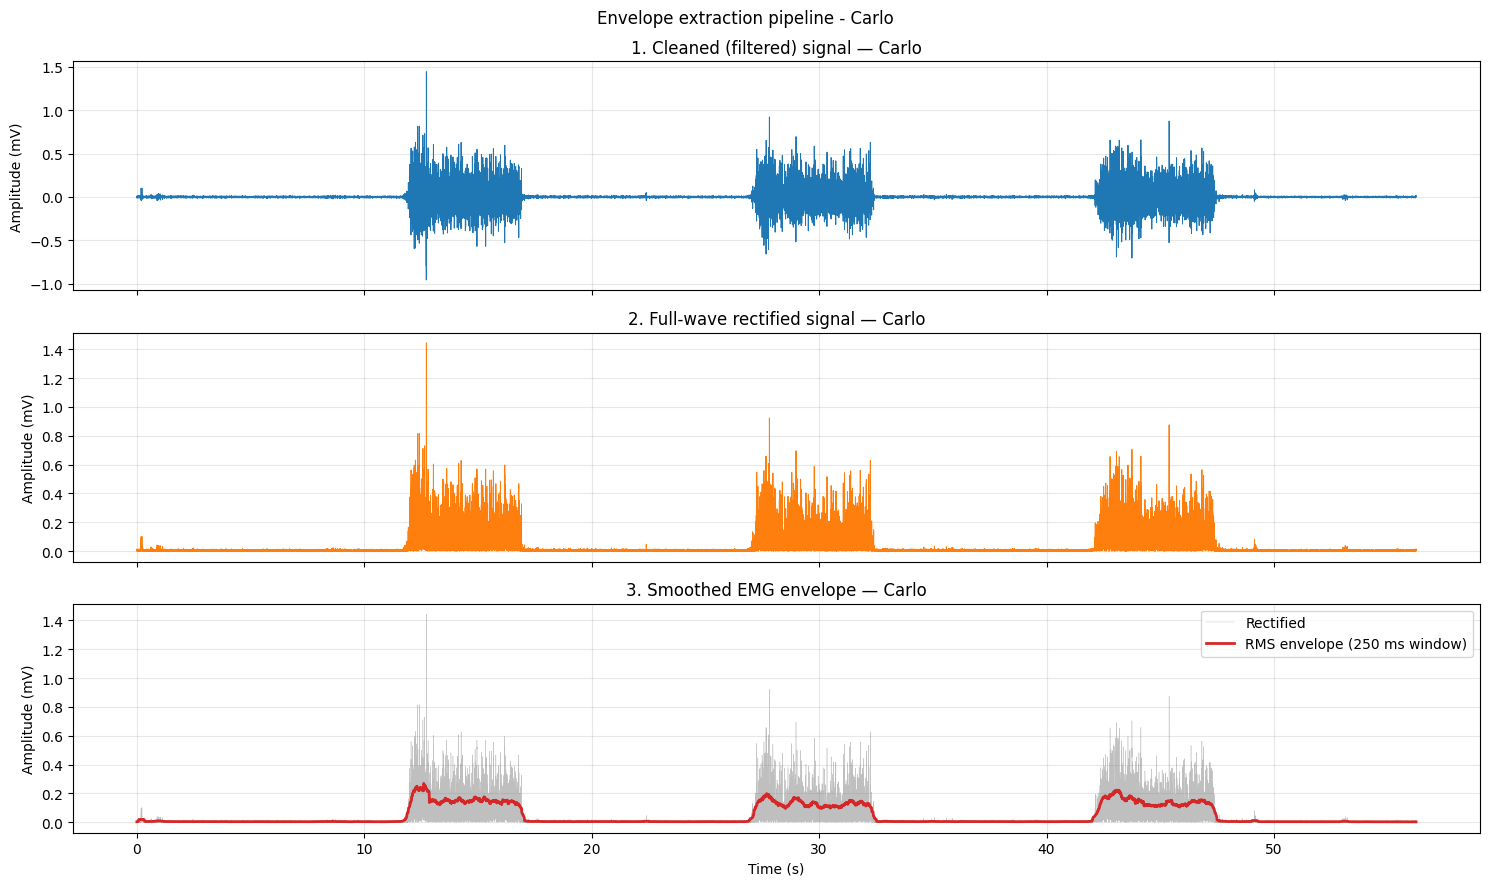

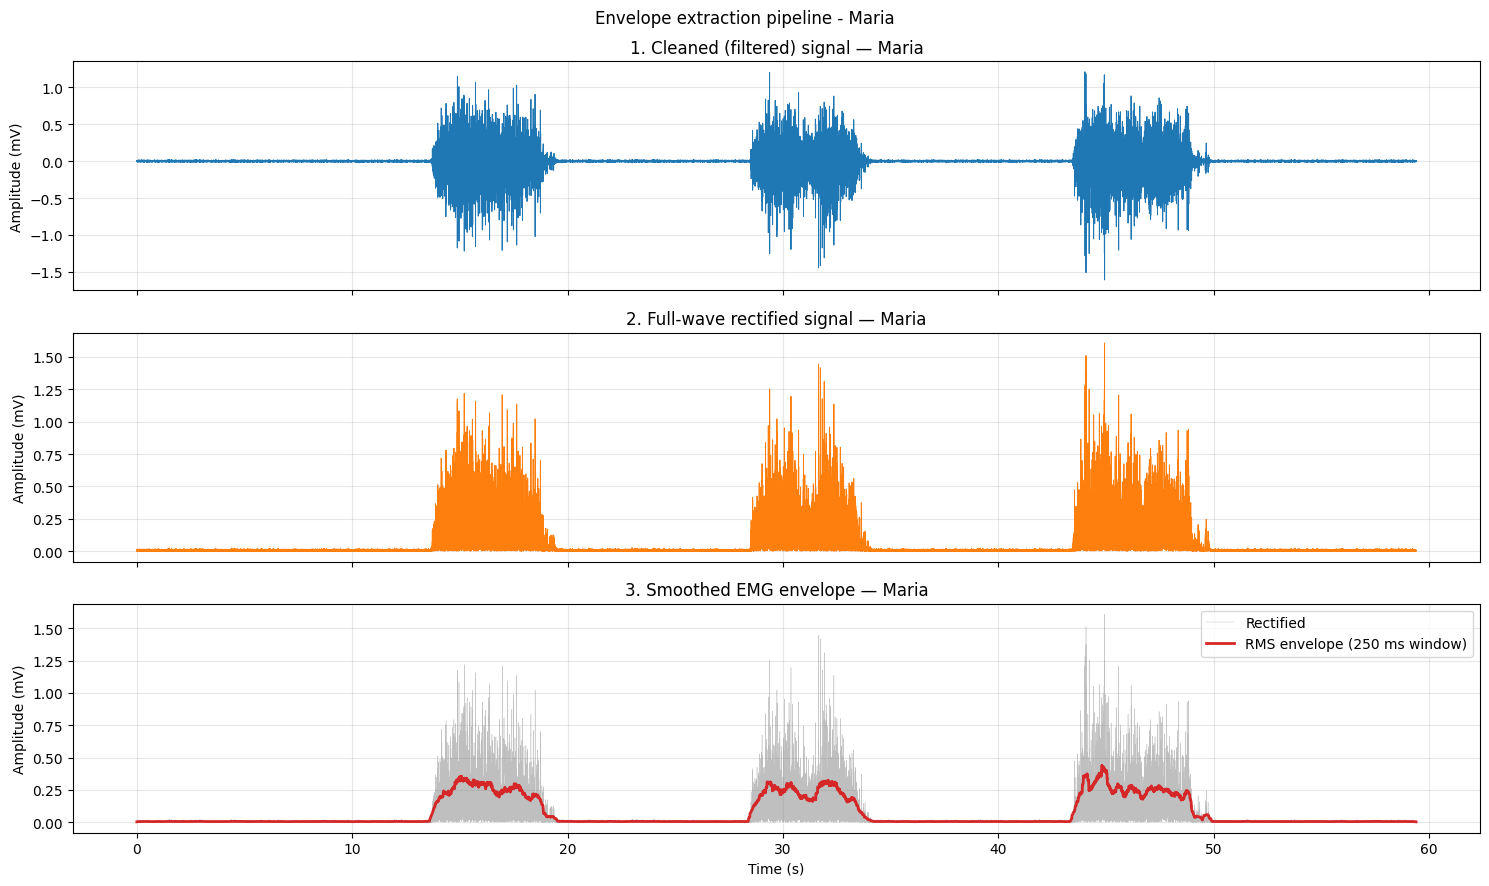

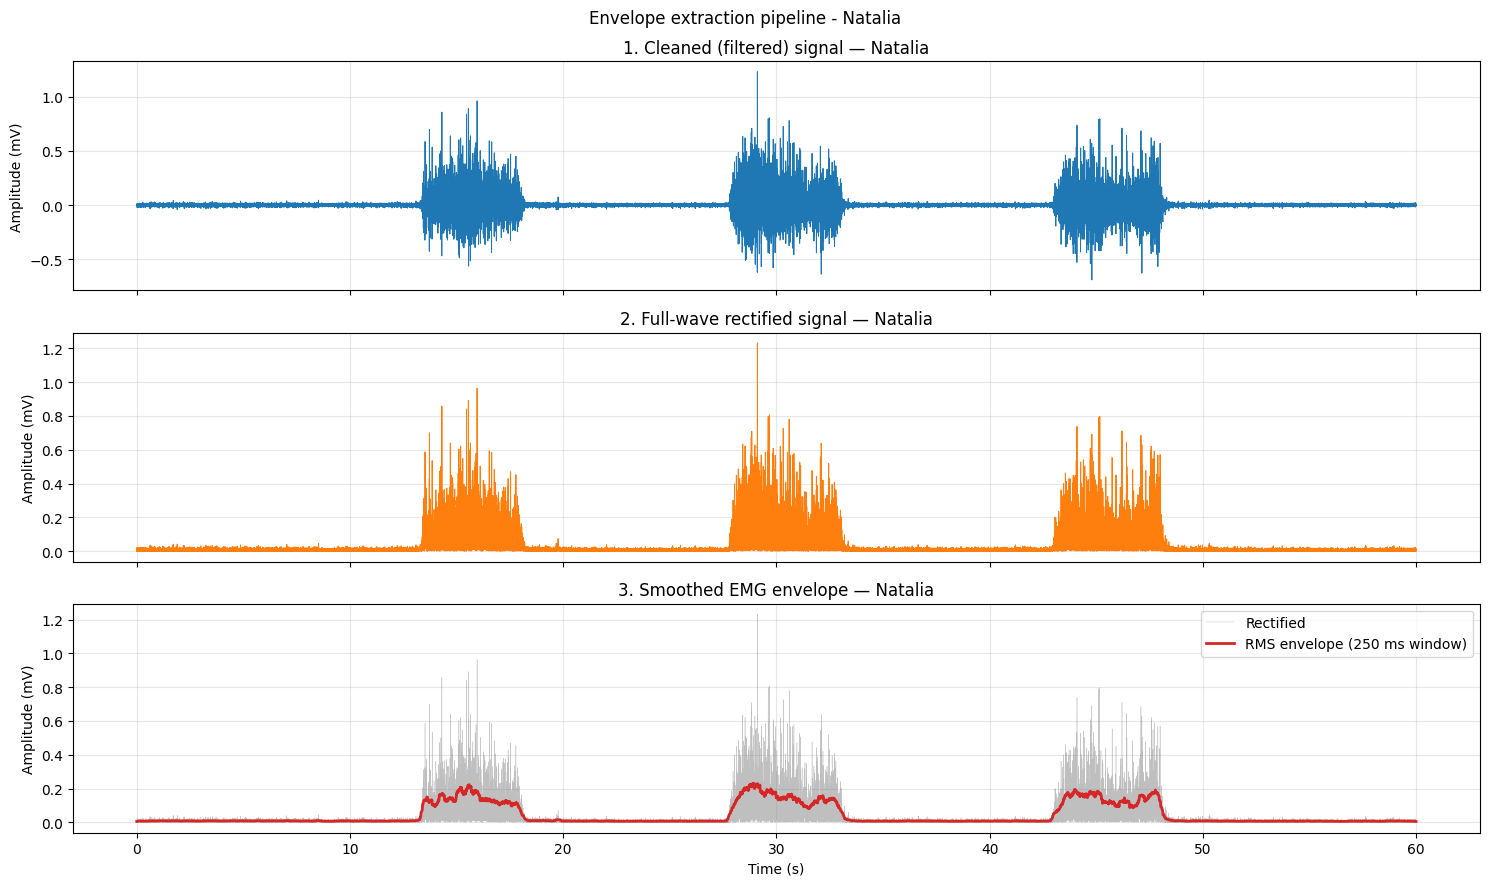

Carlo  (threshold = 0.0225 mV)
  MVC 1: onset= 11.81 s,  offset = 17.04 s,  duration = 5.23 s
  MVC 2: onset= 26.96 s,  offset = 32.49 s,  duration = 5.53 s
  MVC 3: onset= 42.02 s,  offset = 47.49 s,  duration = 5.47 s

Maria  (threshold = 0.0095 mV)
  MVC 1: onset= 13.59 s,  offset = 19.56 s,  duration = 5.97 s
  MVC 2: onset= 28.39 s,  offset = 34.18 s,  duration = 5.79 s
  MVC 3: onset= 43.34 s,  offset = 49.92 s,  duration = 6.57 s

Natalia  (threshold = 0.0125 mV)
  MVC 1: onset= 13.23 s,  offset = 18.31 s,  duration = 5.08 s
  MVC 2: onset= 27.68 s,  offset = 33.48 s,  duration = 5.80 s
  MVC 3: onset= 42.87 s,  offset = 48.53 s,  duration = 5.66 s



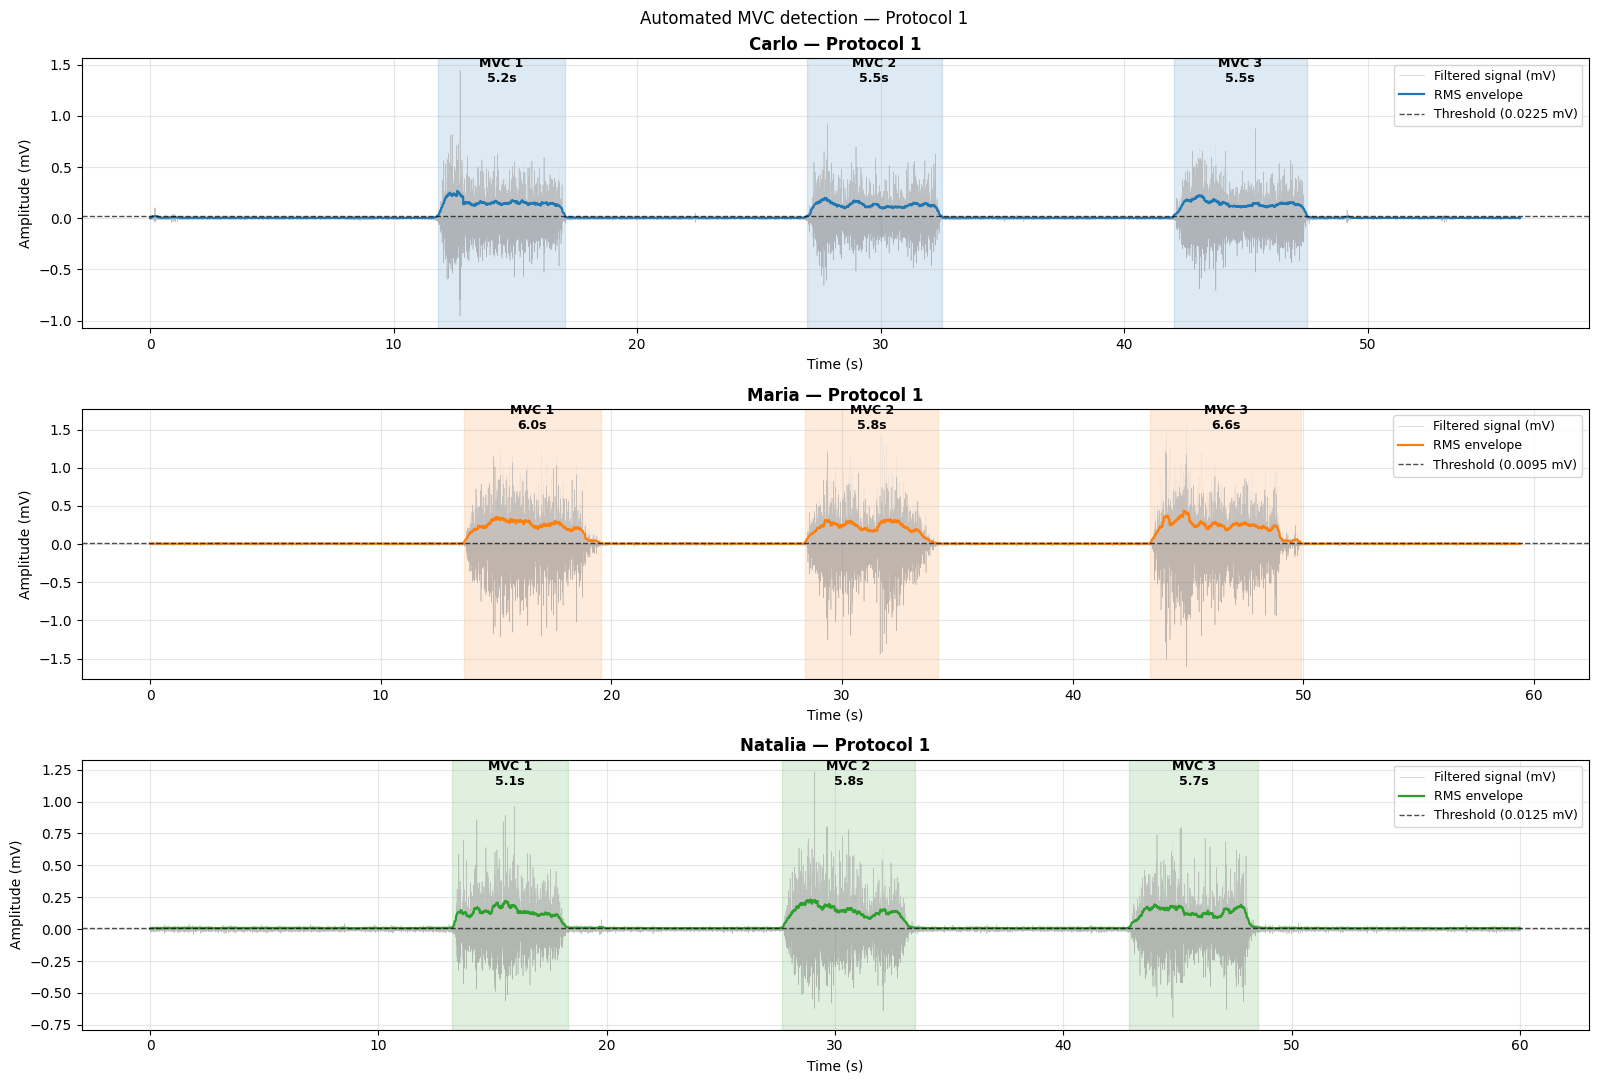

In [ ]:
def apply_rectification(data):
    return np.abs(data) #positive valuse


def apply_rms_smoothing(data,fs=1000, window_size_ms=250):

    window_samples= int((window_size_ms/1000) * fs)
    squared_data= np.power(data, 2)
    window= np.ones(window_samples) /float(window_samples)
    mean_squares= np.convolve(squared_data, window, mode='same')
    return np.sqrt(mean_squares)


# Build rectified and envelope dictionaries for all subjects and protocols
# We compute envelopes for the three protocols
rectified_data_dict={}
envelope_data_dict={}

for subject, signals in filtered_data_dict.items():
    rectified_data_dict[subject]= [apply_rectification(s) for s in signals]
    envelope_data_dict[subject]= [apply_rms_smoothing(s, fs=fs)
                                    for s in rectified_data_dict[subject]]

# Visualization: the three stages of envelope extraction on Protocol 1
protocol_idx =0   #Protocol 1 (MVCs in a quiet environment)

for subject in subjects_names:
    clean_sig= filtered_data_dict[subject][protocol_idx]
    rectified_sig= rectified_data_dict[subject][protocol_idx]
    envelope_sig= envelope_data_dict[subject][protocol_idx]
    time_arr = np.arange(len(clean_sig)) / fs

    fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

    axes[0].plot(time_arr, clean_sig, color='#1f77b4', lw=0.7)
    axes[0].set_title(f"1. Cleaned (filtered) signal — {subject}")
    axes[0].set_ylabel("Amplitude (mV)")
    axes[0].grid(alpha=0.3)

    axes[1].plot(time_arr, rectified_sig, color='#ff7f0e', lw=0.7)
    axes[1].set_title(f"2. Full-wave rectified signal — {subject}")
    axes[1].set_ylabel("Amplitude (mV)")
    axes[1].grid(alpha=0.3)

    axes[2].plot(time_arr, rectified_sig, color='gray', lw=0.3, alpha=0.5,
                 label='Rectified')
    axes[2].plot(time_arr, envelope_sig, color='#d62728', lw=2,
                 label='RMS envelope (250 ms window)')
    axes[2].set_title(f"3. Smoothed EMG envelope — {subject}")
    axes[2].set_ylabel("Amplitude (mV)")
    axes[2].set_xlabel("Time (s)")
    axes[2].legend(loc="upper right")
    axes[2].grid(alpha=0.3)

    plt.suptitle(f"Envelope extraction pipeline - {subject}")
    plt.tight_layout()
    plt.show()


def detect_mvc_events(envelope, fs, noise_window_s=8.0, k=6.0,
                      min_contraction_s=1.5, target_n=3):
  # We set k = 6 and discard any event shorter than 1.5 s (these would be noise spikes rather than real contractions).
  # Detect onset and offset
    # Noise statistics from the resting baseline
    noise_segment =envelope[:int(noise_window_s * fs)]
    threshold =np.mean(noise_segment) + k * np.std(noise_segment)

    # Find threshold crossings (up =onset, down = offset)
    above =(envelope > threshold).astype(int)
    diff=np.diff(above, prepend=0, append=0)
    onsets= np.where(diff == 1)[0]
    offsets= np.where(diff == -1)[0]

    # Keep only events long enough to be real MVCs
    events =[]
    for on, off in zip(onsets, offsets):
        if (off- on) >=int(min_contraction_s *fs):
            events.append((on /fs, off /fs))

    if len(events) != target_n:
        print(f"Warning: expected {target_n} contractions, found {len(events)}. "
              f"Consider adjusting k (current: {k}).")

    return events, threshold


# Apply detector to Protocol 1 for every subject
p1_idx=0
mvc_events= {}
mvc_threshold= {}

for subject in subjects_names:
    envelope =envelope_data_dict[subject][p1_idx]
    events, thr= detect_mvc_events(envelope, fs)
    mvc_events[subject]= events
    mvc_threshold[subject]= thr

    print(f"{subject}  (threshold = {thr:.4f} mV)")
    for i, (on, off) in enumerate(events):
        print(f"  MVC {i+1}: onset= {on:.2f} s,  "
              f"offset = {off:.2f} s,  duration = {off-on:.2f} s")
    print()

# Visualization: filtered signal + envelope + threshold + shaded MVCs
fig, axes = plt.subplots(3, 1, figsize=(16, 11))

for i, subject in enumerate(subjects_names):
    filtered_sig= filtered_data_dict[subject][p1_idx]
    envelope= envelope_data_dict[subject][p1_idx]
    t= np.arange(len(envelope))/ fs

    ax =axes[i]
    ax.plot(t, filtered_sig, color='gray', lw=0.4, alpha=0.5,
            label='Filtered signal (mV)')
    ax.plot(t, np.abs(filtered_sig), color='lightgray', lw=0.3, alpha=0.4)
    ax.plot(t, envelope, color=colors[i], lw=1.6, label='RMS envelope')
    ax.axhline(mvc_threshold[subject], color='black', lw=1.0,
               linestyle='--', alpha=0.7,
               label=f'Threshold ({mvc_threshold[subject]:.4f} mV)')

    for j, (on, off) in enumerate(mvc_events[subject]):
        ax.axvspan(on, off, alpha=0.15, color=colors[i])
        ax.text((on + off) / 2, ax.get_ylim()[1] * 0.85,
                f'MVC {j+1}\n{off-on:.1f}s',
                ha='center', fontsize=9, fontweight='bold')

    ax.set_title(f"{subject} — Protocol 1", fontweight='bold')
    ax.set_ylabel("Amplitude (mV)")
    ax.set_xlabel("Time (s)")
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Automated MVC detection — Protocol 1")
plt.tight_layout()
plt.show()


4.2. Feature Extraction: Calculating the Root Mean Square (RMS) for each contraction.$$RMS = \sqrt{\frac{1}{N} \sum_{i=1}^{N} x_i^2}$$



In [ ]:
#RMS calculation
def compute_rms(segment):
    return np.sqrt(np.mean(segment ** 2))


rms_per_subject= {}

for subject in subjects_names:
    filtered_sig= filtered_data_dict[subject][p1_idx]
    rms_values=[]

    for on, off in mvc_events[subject]:
        segment= filtered_sig[int(on * fs) : int(off * fs)]
        rms_values.append(compute_rms(segment))

    rms_per_subject[subject] =rms_values

    print(f"{subject}")
    for i, v in enumerate(rms_values):
        print(f"  MVC {i+1}: {v:.4f} mV")
    print(f"  Mean RMS: {np.mean(rms_values):.4f} mV\n")

Carlo
  MVC 1: 0.1577 mV
  MVC 2: 0.1289 mV
  MVC 3: 0.1426 mV
  Mean RMS: 0.1430 mV

Maria
  MVC 1: 0.2365 mV
  MVC 2: 0.2211 mV
  MVC 3: 0.2398 mV
  Mean RMS: 0.2325 mV

Natalia
  MVC 1: 0.1366 mV
  MVC 2: 0.1446 mV
  MVC 3: 0.1340 mV
  Mean RMS: 0.1384 mV



4.3. Comparative Results: Tables and Bar Charts comparing RMS values across the 3 team members.


In [ ]:
rms_rows = []

for subject in subjects_names:
    values = rms_per_subject[subject]
    rms_rows.append({
        'Subject'        : subject,
        'MVC 1 RMS (mV)' : round(values[0], 4),
        'MVC 2 RMS (mV)' : round(values[1], 4),
        'MVC 3 RMS (mV)' : round(values[2], 4),
        'Mean RMS (mV)'  : round(np.mean(values), 4)
    })

df_rms = pd.DataFrame(rms_rows)
df_rms

,Subject,MVC 1 RMS (mV),MVC 2 RMS (mV),MVC 3 RMS (mV),Mean RMS (mV)
0,Carlo,0.1577,0.1289,0.1426,0.1430
1,Maria,0.2365,0.2211,0.2398,0.2325
2,Natalia,0.1366,0.1446,0.1340,0.1384


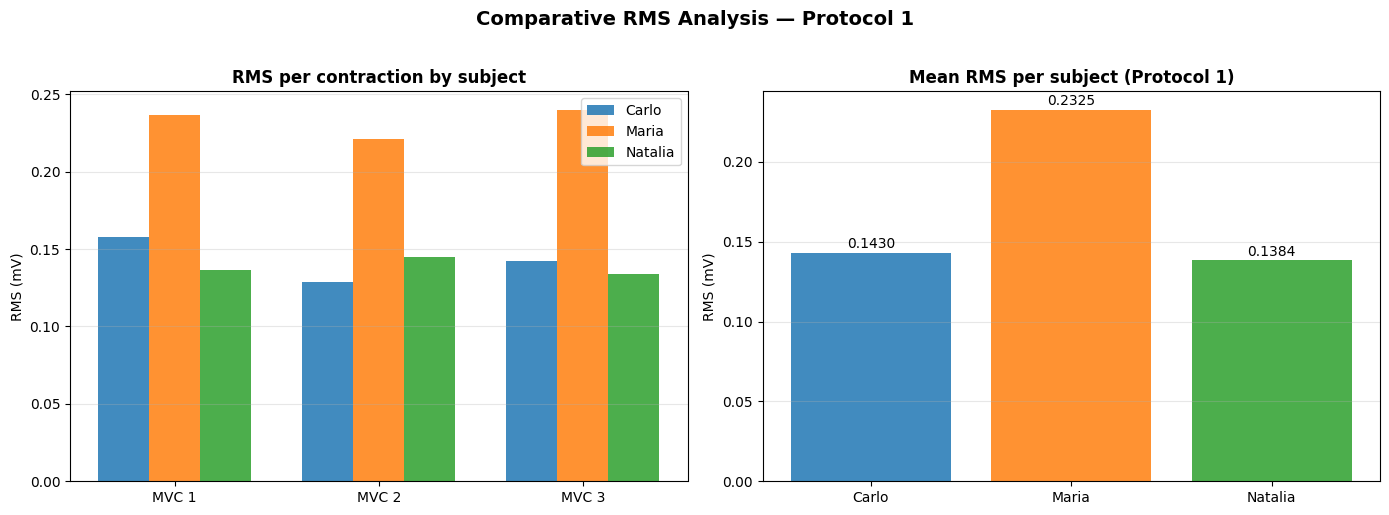

In [ ]:
fig, axes=plt.subplots(1, 2, figsize=(14, 5))

#RMS of each contraction per subject
x=np.arange(3)
width= 0.25

for i, subject in enumerate(subjects_names):
    axes[0].bar(x +i * width, rms_per_subject[subject], width,
                label=subject, color=colors[i], alpha=0.85)

axes[0].set_title("RMS per contraction by subject", fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(['MVC 1', 'MVC 2', 'MVC 3'])
axes[0].set_ylabel("RMS (mV)")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

#average of RMS per subject
mean_values=[np.mean(rms_per_subject[s]) for s in subjects_names]

bars =axes[1].bar(subjects_names, mean_values, color=colors[:3], alpha=0.85)

for bar, val in zip(bars, mean_values):
    axes[1].text(bar.get_x() + bar.get_width() /2,
                 val + 0.001, f'{val:.4f}',
                 ha='center', va='bottom')

axes[1].set_title("Mean RMS per subject (Protocol 1)", fontweight='bold')
axes[1].set_ylabel("RMS (mV)")
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Comparative RMS Analysis — Protocol 1", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

####4.4. Physiological Discussion: Why does Subject B (María) show the highest RMS amplitude despite physiological expectations? (Muscle cross-sectional area vs. subcutaneous fat layer).

The RMS values obtained reflect the amplitude of the myoelectric signal recorded at the skin surface and are influenced by several physiological and experimental factors.

**Muscle cross-sectional area and sex differences:** Larger muscles generate a higher number of simultaneous motor unit action potentials (MUAPs), which increases the amplitude of the interference pattern captured by the electrodes. Male subjects generally have a larger forearm muscle cross-sectional area, which would theoretically predict higher RMS values for Carlo. However, our results show the opposite: Subject B (María) recorded the highest amplitude across all three MVCs.

**Experimental limitation** Subject A (Carlo): As noted in the subject metadata, Carlo's signal saturated during true MVC, so he performed at a submaximal level. This directly reduced his RMS values despite his larger muscle mass, and is the primary factor explaining why his amplitude falls below María's.

**Contraction duration:** Visual inspection of the RMS envelope also reveals that Subject B (María) maintained the contraction for slightly longer than the other subjects. This extended duration means the RMS window captures a longer period of sustained high-frequency motor unit recruitment, which contributes to higher peak amplitude values.

**Physical conditioning:** Both Natalia (gym-based resistance training) and María (rugby player) maintain active lifestyles, which may result in better motor unit recruitment efficiency compared to a sedentary subject. This could explain similarities in their RMS values despite differences in body composition and muscle mass.

**Subcutaneous tissue thickness:** The fat layer between the muscle and the skin acts as a low-pass spatial filter, attenuating the signal amplitude before it reaches the electrodes. Subjects with a thicker subcutaneous layer tend to show lower RMS values independently of the actual force produced.

## 5. Assessment of Power Line Interference (Protocol 1 vs. Protocol 2)


### 5.1. Signal-to-Noise Ratio (SNR) Estimation: Comparing "Quiet" vs. "Close to Socket" environments

To quantify the impact of Power Line Interference (PLI), we calculate the Signal-to-Noise Ratio (SNR) for each subject under both experimental conditions: Protocol 1 (Quiet) and Protocol 2 (Close to socket).

We estimate the SNR using the Root Mean Square (RMS) of the active muscle contraction phase against the RMS of the resting baseline phase. The formula used is:

$SNR_{dB} = 20 \cdot \log_{10} \left( \frac{RMS_{active}}{RMS_{rest}} \right)$

**Methodology:**
* **Noise ($RMS_{rest}$):** Extracted from a quiet baseline window before the contraction begins.
* **Signal ($RMS_{active}$):** Extracted from a window during the Maximum Voluntary Contraction (MVC).
* We run this analysis on the **raw data** (`data_dict`) rather than the filtered data to observe the true environmental interference before any software correction is applied.

In [ ]:
#Function to calculate SNR
def estimate_snr(signal_array, fs, rest_start, rest_end, active_start, active_end):

    #Define sample indices
    rest_window=signal_array[int(rest_start * fs) :int(rest_end * fs)]
    active_window= signal_array[int(active_start * fs) :int(active_end * fs)]

    #Calculate RMS for both windows
    rms_rest= np.sqrt(np.mean(rest_window**2))
    rms_active= np.sqrt(np.mean(active_window**2))

    #Calculate SNR in dB
    snr_db= 20 * np.log10(rms_active / (rms_rest + 1e-9))

    return snr_db

#Define specific windows for each subject based on visual inspection
#'SubjectName': (rest_start, rest_end, active_start, active_end)
subject_windows = {
    "Carlo":   (2.0, 10.0, 12.0, 16.0),
    "Maria":   (2.0, 10.0, 14.0, 18.0),
    "Natalia": (2.0, 10.0, 14.0, 17.0)
}

snr_results = []
p1_idx= 0 #Protocol 1
p2_idx= 1 #Protocol 2

print("Calculating raw SNR for protocols 1 and 2 with subject specific windows")

for subject in data_dict.keys():
    #Extract the specific windows for this subject
    r_start, r_end, a_start, a_end = subject_windows[subject]

    sig_p1 = data_dict[subject][p1_idx]
    sig_p2 = data_dict[subject][p2_idx]

    #Calculate SNR using their specific timing
    snr_p1 = estimate_snr(sig_p1, fs, r_start, r_end, a_start, a_end)
    snr_p2 = estimate_snr(sig_p2, fs, r_start, r_end, a_start, a_end)

    snr_results.append({
        'Subject': subject,
        'Protocol 1 SNR (dB) - Quiet': round(snr_p1, 2),
        'Protocol 2 SNR (dB) - Socket': round(snr_p2, 2),
        'Degradation (dB)': round(snr_p1 - snr_p2, 2)
    })

df_snr = pd.DataFrame(snr_results)
df_snr

Calculating raw SNR for protocols 1 and 2 with subject specific windows


,Subject,Protocol 1 SNR (dB) - Quiet,Protocol 2 SNR (dB) - Socket,Degradation (dB)
0,Carlo,27.69,2.95,24.74
1,Maria,29.21,3.81,25.40
2,Natalia,24.59,5.19,19.40


**Preliminary Observations:**


As expected, the SNR drops significantly in Protocol 2 for all subjects. The proximity to the electrical socket dramatically increases the baseline noise (the denominator in our SNR equation), heavily degrading the overall quality of the recording. This quantitative data aligns with the visual thick baseline observed in our initial data exploration.

### 5.2. Spectral Fingerprinting: Identifying the 50 Hz PLI Harmonic

To confirm that the noise introduced in Protocol 2 is indeed Power Line Interference (PLI), we analyze the frequency content of the signals. We utilize **Welch's Method** to estimate the Power Spectral Density (PSD).

Instead of analyzing the whole signal, we specifically isolate the **resting baseline window** (2.0s to 8.0s). During this period, the muscles are completely relaxed, meaning any high-power frequency components are purely artifacts or environmental noise.

* **Protocol 1 (Quiet):** Should display a relatively flat, low-power spectrum.
* **Protocol 2 (Socket):** Should display a distinct, high-power at exactly 50 Hz (the European power grid fundamental frequency) and potentially at its  harmonics (100 Hz, 150 Hz, 200 Hz, 250 Hz, etc).

Generating Spectral Fingerprints (PSD) for resting periods


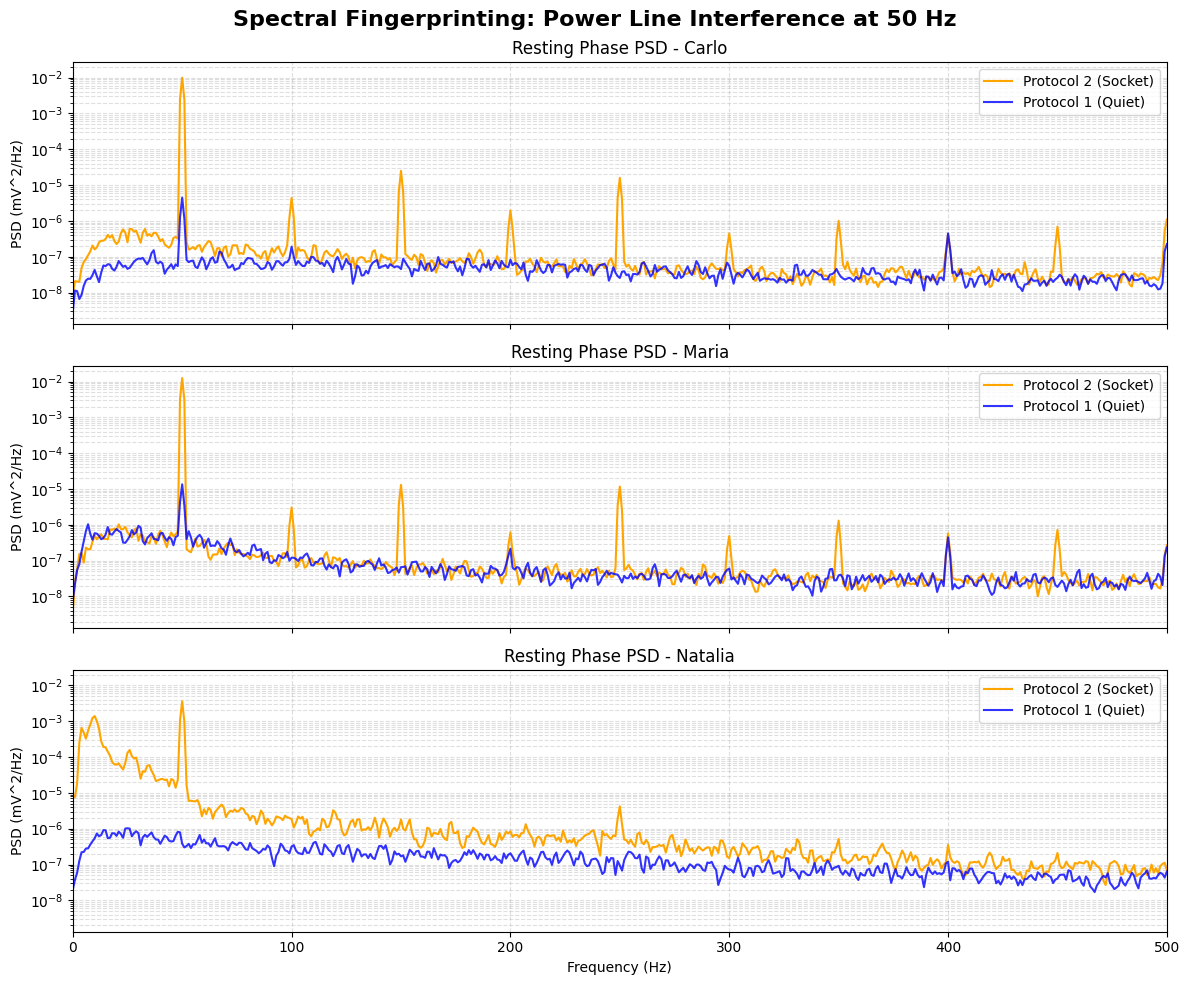

In [ ]:
#We will use the consistent resting window from 2s to 8s
rest_start= 2
rest_end= 8

#Set up the plot: 3 rows (one for each subject), 1 column
fig, axes =plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)

print("Generating Spectral Fingerprints (PSD) for resting periods")

for i, subject in enumerate(data_dict.keys()):
    #Extracting raw signals for P1 and P2
    sig_p1 =data_dict[subject][0] #Quiet
    sig_p2 =data_dict[subject][1] #Socket

    #Isolate the resting windows
    rest_p1=sig_p1[int(rest_start *fs) :int(rest_end* fs)]
    rest_p2=sig_p2[int(rest_start *fs) :int(rest_end* fs)]

    #Compute Welch periodogram
    #nperseg=1000 gives us a clean 1 Hz frequency resolution (since fs=1000)
    freqs_p1,psd_p1= signal.welch(rest_p1,fs,nperseg=1000)
    freqs_p2,psd_p2= signal.welch(rest_p2,fs,nperseg=1000)

    #Plotting
    ax=axes[i]

    #Plot Protocol 2 first (the noisy one) so Protocol 1 sits neatly on top
    ax.semilogy(freqs_p2,psd_p2, color='orange', label='Protocol 2 (Socket)')
    ax.semilogy(freqs_p1,psd_p1, color='blue', label='Protocol 1 (Quiet)', alpha=0.8)

    ax.set_title(f"Resting Phase PSD - {subject}")
    ax.set_ylabel("PSD (mV^2/Hz)")
    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc='upper right')

    #We limit the x-axis to 500 Hz because PLI is 50 Hz, and sEMG energy drops off after 500 Hz anyway
    ax.set_xlim(0, 500)

#Bottom axis label
axes[-1].set_xlabel("Frequency (Hz)")

plt.suptitle("Spectral Fingerprinting: Power Line Interference at 50 Hz", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Spectral Observations:**

The Welch periodograms clearly validate the presence of Power Line Interference.

In the Protocol 2 (Orange) recordings, there is a massive spike in signal power located exactly at 50 Hz. In some subjects, we can also observe a smaller secondary spike at 150 Hz, which is the 3rd harmonic of the power grid frequency. Conversely, Protocol 1 (Blue) maintains a relatively flat and low-power noise floor, confirming that physical distance from electrical sockets is a highly effective preventative measure against PLI.

The best example in this case are Carlo and Maria signals, where we can clearly see the big spikes at 50 Hz, 100 Hz, 150 Hz, etc.

### 5.3. Filter Validation: Quantitative Comparison of SNR Before and After Filtering

In Section 3.2.2, we implemented a 50 Hz recursive IIR Notch filter specifically designed to target the Power Line Interference (PLI) observed in Protocol 2.

While visual inspection suggested the baseline noise was reduced, it is necessary to quantify this improvement. To do this, we calculate the Signal-to-Noise Ratio (SNR) of the *filtered* Protocol 2 signals using the same subject-specific resting and active windows defined in Section 5.1. We then compare these new SNR values against the raw SNR values to measure the exact recovery of signal quality in decibels (dB).

In [ ]:
print("Validating Notch Filter Effectiveness for Protocol 2...")

#A list to hold our filter validation results
filter_results= []
p2_idx= 1 #Only Protocol 2 (close to socket) for this test

for subject in filtered_data_dict.keys():
    #Specific windows for this subject (defined in 5.1)
    r_start, r_end, a_start, a_end = subject_windows[subject]

    #Extract the raw and filtered signals for Protocol 2
    sig_p2_raw= data_dict[subject][p2_idx]
    sig_p2_filtered= filtered_data_dict[subject][p2_idx]

    #Calculate SNR for both versions
    snr_raw= estimate_snr(sig_p2_raw, fs, r_start, r_end, a_start, a_end)
    snr_filtered= estimate_snr(sig_p2_filtered, fs, r_start, r_end, a_start, a_end)

    filter_results.append({
        'Subject': subject,
        'Protocol 2 - Raw SNR (dB)': round(snr_raw, 2),
        'Protocol 2 - Filtered SNR (dB)': round(snr_filtered, 2),
        'Improvement (dB)': round(snr_filtered - snr_raw, 2)
    })

#DataFrame for nice visualization
df_filter_val= pd.DataFrame(filter_results)

df_filter_val

Validating Notch Filter Effectiveness for Protocol 2...


,Subject,Protocol 2 - Raw SNR (dB),Protocol 2 - Filtered SNR (dB),Improvement (dB)
0,Carlo,2.95,20.86,17.91
1,Maria,3.81,25.22,21.41
2,Natalia,5.19,13.58,8.39


**Validation Results:**


The comparison confirms the efficacy of the 50 Hz Notch filter. Across all subjects, applying the filter to the Protocol 2 recordings yielded a massive improvement in SNR. By effectively zeroing out the high-power 50 Hz noise floor, the baseline RMS decreased significantly, which rescued the overall Signal to Noise ratio (SNR). This proves that our preprocessing pipeline successfully recovers highly contaminated signals, making them viable for further amplitude and temporal analysis.

We can observe that Maria had a massive improvement while Natalia got a lower improvement that can be caused due to the motion artifact at 20s.

### 5.4. Discussion: Impact of Environmental Noise on the Reliability of Clinical sEMG Measurements

The quantitative results from our SNR analysis clearly demonstrate the severe impact of environmental electromagnetic interference on biomedical signal acquisition.

When the BITalino device was placed close to an electrical socket (Protocol 2), the raw Signal to Noise Ratio (SNR) decreased to critically low levels (ranging from 2.95 dB to 5.19 dB). At this level of contamination, the 50 Hz Power Line Interference (PLI) effectively masked the real myoelectric activity. In a clinical setting, relying on this raw data would lead to highly unreliable estimations of muscle force, timing, and fatigue.

However, the implementation of a 50 Hz recursive IIR Notch filter successfully recovered the signal integrity. As shown in our Filter Validation table, the SNR improved drastically across all subjects. For instance, Subject B (Maria) saw an improvement of +21.41 dB, indicating that the filter successfully eliminated the PLI and restored the baseline to near-resting levels.

It is also worth noting the limitations of targeted filtering.

Subject C (Natalia) exhibited the lowest final SNR (13.58 dB) and the smallest improvement (+8.39 dB). As noted during our initial visual inspection, Subject C's recording contained a large motion artifact. Because the Notch filter strictly targets the 50 Hz frequency bin, it cannot remove broad spectrum or low frequency motion artifacts.





**Conclusion:**

While software based filtering (like Notch and Band-Pass filters) is a highly effective tool for rescuing contaminated data, the most reliable method for ensuring high quality sEMG recordings is a proper physical experimental design. Maximizing the physical distance from electrical sockets remains the optimal strategy for preventing PLI.

## 6. Spectral Analysis: Muscle Fatigue Study (Protocol 3)



### 6.0. Preprocessing Validation: Ensuring the use of non-rectified, filtered signals (Band-pass + Notch).
Before jumping into the fatigue study, we have to make sure we are using the right version of our signal. In Section 3, we built a pipeline that cleans the noise (filtering) and then calculates the "outline" of the muscle contraction (rectification and smoothing).
For spectral analysis, we only use the filtered signal (Band-pass+Notch), skipping the rectification and smoothing stages. The reasons for this decision were:
*   Preserving oscillations: Spectral analysis looks at how fast the muscle fibers are firing. Rectification (taking the absolute value) and smoothing (the envelope) essentially removes these fast oscillations to show us amplitude
*    Fiter's choice: We chose a 4th-order Butterworth IIR filter because it is fast and doesn't distort the signal. Its "flat" response allows us to strip away noise (20-450 Hz) while keeping the muscle data intact. We used an IIR design specifically because it provides a sharp cutoff without needing much computing power

#### 6.1. Endurance Windowing: Extraction of the "fresh" stage (first 10s) and the "fatigued" stage (last 10s) of the sustained contraction.
We study in class that during sustained muscle contractions, fatigue is characterized by a decrease in the conduction velocity of action potentials along the muscle fibers. As the muscle is contracting, these electrical discharges propagate more slowly, which effectively broadens the duration of the motor unit action potentials (MUAPs) in the time domain. This temporal expansion causes a spectral compression, shifting the power of the EMG signal toward lower frequencies. Furthermore, the central nervous system may increase motor unit synchronization to maintain force, which also contributes to the shift in the frequency distribution.
We calculate the first and last 10 seconds:

In [ ]:
window_duration=10
window_samples=window_duration* fs

fresh_data={}
fatigued_data={}

for name in subjects_names:
    # selection of the filtred signal of protocol 3 (Without the enveloe)
    full_signal=filtered_data_dict[name][2]

    # 10 first sec
    fresh_data[name]=full_signal[:window_samples]

    # 10 last sec
    fatigued_data[name]=full_signal[-window_samples:]

###6.2. Power Spectral Density (PSD): Welch’s Periodogram
Firstly we compare the periodogram function (it's a fft) with the Welch's periodogram to see what's the better visualization of the noise.
We used a logarithmic scale (semilogy) for the PSD plots to better manage the signal's dynamic range. In EMG signals, the power at lower frequencies is often thousands of times higher than at higher frequencies.

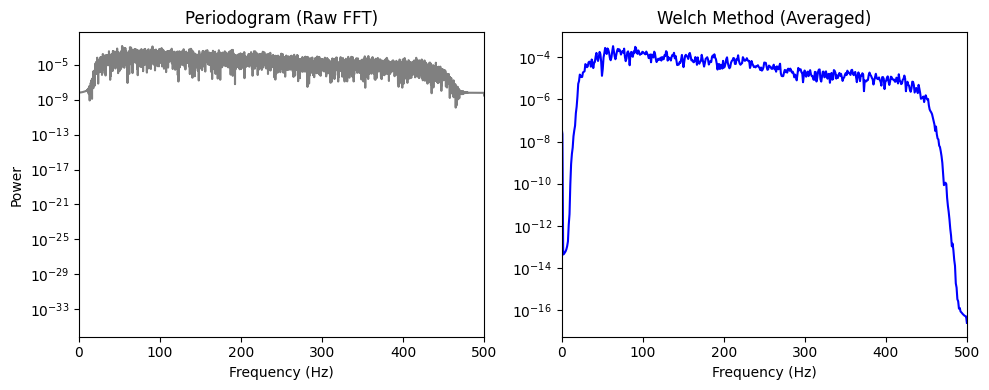

In [ ]:
sig =fresh_data["Carlo"]

# Periodogram
f1, p1=signal.periodogram(sig,fs=fs)

# Welch
f2, p2=signal.welch(sig, fs=fs,nperseg=1024)

fig,axs= plt.subplots(1, 2,figsize=(10, 4))

axs[0].semilogy(f1, p1, color='gray')
axs[0].set_title("Periodogram (Raw FFT)")
axs[0].set_xlabel("Frequency (Hz)")
axs[0].set_ylabel("Power")
axs[0].set_xlim(0,500)

axs[1].semilogy(f2, p2, color='blue')
axs[1].set_title("Welch Method (Averaged)")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_xlim(0,500)

plt.tight_layout()
plt.show()

Welch’s method significantly reduces spectral variance (noise), providing the stable and smooth PSD curve required for accurate fatigue analysis. This reduce of variation confirms what we study in the theoretical part of the course.

Now we code the estimation for all subejcts in the two moments, fresh and fatigued.

In [ ]:
psd_results={}

for name in subjects_names:
    # fresh
    f_fresh, p_fresh= signal.welch(fresh_data[name], fs=fs, nperseg=1024)

    # fatigued
    f_fatigued, p_fatigued= signal.welch(fatigued_data[name], fs=fs, nperseg=1024)

    # storing the data
    psd_results[name]= {
        "fresh": (f_fresh, p_fresh),
        "fatigued": (f_fatigued, p_fatigued)
    }

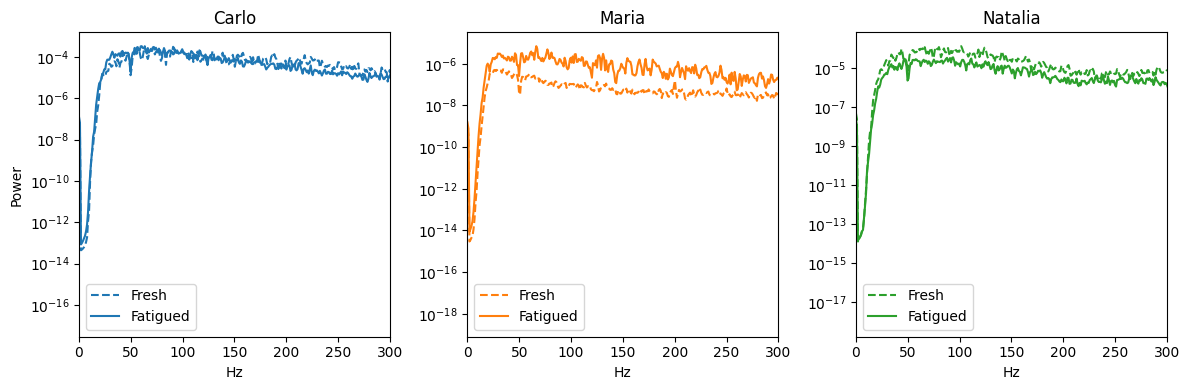

In [ ]:
fig, axes=plt.subplots(1, 3, figsize=(12, 4))

for i, name in enumerate(subjects_names):
    f_in,p_in=psd_results[name]['fresh']
    f_fi,p_fi=psd_results[name]['fatigued']

    # Fresh (dotted) y Fatigued (solid)
    axes[i].semilogy(f_in, p_in,color=colors[i], linestyle='--', label='Fresh')
    axes[i].semilogy(f_fi, p_fi,color=colors[i], label='Fatigued')

    axes[i].set_title(name)
    axes[i].set_xlim(0,300)
    axes[i].set_xlabel("Hz")
    if i == 0:
        axes[i].set_ylabel("Power")
    axes[i].legend()

plt.tight_layout()
plt.show()

These plots show the power spectrum for each subject at the start and end of the protocol. The PSD plots confirm muscle fatigue in all three subjects.
Differences between subjects reflect their physical condition. In Maria (untrained), we see a significant increase in total power during the fatigued stage, likely due to massive motor unit recruitment to compensate for lack of endurance. In Natalia (gym trained), the 'Fresh' curve stays above the 'Fatigued' curve at high frequencies, showing a classic spectral compression without needing as much recruitment compensation. Carlo shows high stability, suggesting a lower level of fatigue for the same load.


### 6.3. Spectral Descriptors Calculation:


####6.3.1. Mean Frequency (MNF): The mathematical centroid of the power spectrum.
The Mean Frequency is the average frequency of the power spectrum. We calculate it by weighting each frequency by its power. Is a direct indicator of Conduction Velocity. When the muscle fibers fatigue, the electrical action potentials propagate more slowly, which causes the MNF to decrease. Therefore, a drop in this value confirms that peripheral fatigue has happen.
The formula we use is:$$\text{MNF} = \frac{\sum f \cdot P(f)}{\sum P(f)}$$


In [ ]:
for name in subjects_names:
    # recover data
    f_fresh, p_fresh= psd_results[name]['fresh']
    f_fatigued, p_fatigued = psd_results[name]['fatigued']
    # formula
    mnf_fresh =np.sum(f_fresh * p_fresh)/np.sum(p_fresh)
    mnf_fatigued= np.sum(f_fatigued * p_fatigued) / np.sum(p_fatigued)

    print(f"Fresh:{mnf_fresh:.2f} Hz")
    print(f"Fatigued:{mnf_fatigued:.2f} Hz")
    print(f"Drop:{mnf_fresh - mnf_fatigued:.2f} Hz\n")

Fresh:143.99 Hz
Fatigued:109.94 Hz
Drop:34.05 Hz

Fresh:127.90 Hz
Fatigued:115.90 Hz
Drop:12.00 Hz

Fresh:114.52 Hz
Fatigued:116.07 Hz
Drop:-1.54 Hz



####6.3.2. Median Frequency (MDF): The frequency that divides the spectrum into two regions of equal power.
The Median Frequency is the frequency that divides the power spectrum into two equal halves. It is the point where 50% of the signal's power is below it and 50% is above. It is often more stable than the MNF because it is less affected by random noise at the edges of the spectrum.
Formula:
$$\sum_{f=0}^{MDF} P(f) = \sum_{f=MDF}^{f_{max}} P(f) = \frac{1}{2} \sum_{f=0}^{f_{max}} P(f)$$

In [ ]:
for name in subjects_names:
    # recover data
    f_fresh, p_fresh =psd_results[name]['fresh']
    f_fatigued, p_fatigued =psd_results[name]['fatigued']

    # we search were the cumulative sum is the 50%
    mdf_fresh =f_fresh[np.where(np.cumsum(p_fresh)>=np.sum(p_fresh)/2)[0][0]]
    mdf_fatigued =f_fatigued[np.where(np.cumsum(p_fatigued)>=np.sum(p_fatigued)/2)[0][0]]

    print(f"Fresh: {mdf_fresh:.2f} Hz")
    print(f"Fatigued: {mdf_fatigued:.2f} Hz")
    print(f"Drop: {mdf_fresh - mdf_fatigued:.2f} Hz\n")

Fresh: 121.09 Hz
Fatigued: 89.84 Hz
Drop: 31.25 Hz

Fresh: 74.22 Hz
Fatigued: 89.84 Hz
Drop: -15.62 Hz

Fresh: 98.63 Hz
Fatigued: 96.68 Hz
Drop: 1.95 Hz




####6.3.3. Total Power (Area under PSD)
Total Power is the integral of the PSD across all frequencies. Is the amplitude estimation.
Physiologically, if we observe an increase in total power while the MNFdecreases, it confirms that the subject is compensating for fatigue by recruiting more Motor Units or increasing their firing rate to maintain the required force.Formula:$$Total Power = \int_{0}^{f_{max}} P(f) df$$

In [ ]:
for name in subjects_names:
    # recover data
    f_fresh, p_fresh =psd_results[name]['fresh']
    f_fatigued, p_fatigued =psd_results[name]['fatigued']

    # formula: total power (Area above the curve)
    pow_fresh=np.trapezoid(p_fresh, f_fresh)
    pow_fatigued=np.trapezoid(p_fatigued, f_fatigued)

    # %
    change=((pow_fatigued - pow_fresh) / pow_fresh) * 100

    print(f"Fresh: {pow_fresh:.2e}")
    print(f"Fatigued: {pow_fatigued:.2e}")
    print(f"Change: {change:.2f}%\n")

Fresh: 2.45e-02
Fatigued: 2.32e-02
Change: -5.39%

Fresh: 3.26e-05
Fatigued: 2.98e-04
Change: 814.46%

Fresh: 9.23e-03
Fatigued: 2.72e-03
Change: -70.48%



### 6.4. Quantitative Comparison and Discussion: The "Fatigue Shift" and Physiological mechanisms.

Although we have discuss the physiological mechanisms during the whole 6 part of spectral analysis, here we compare the differences with the last parameters computed.


* Subject 1: Carlo (Male-Fast Fatigue).
We observed a huge drop in both MNF (34 Hz) and MDF (31 Hz). Mechanism: As a male, Carlo likely has a higher percentage of Type II fibers (fast-twitch), which are capable of generating more force but fatigue much faster. The drop in frequency confirms a significant reduction in the conduction velocity of action potentials. His power remained stable because his body didn't (or couldn't) recruit more fibers to compensate.


* Subject 2: Maria (Untrained-Neural Drive)
While her frequency drop was moderate (12 Hz), her Total Power is  814%.
Being untrained, her muscle fibers likely started to fail early. To keep the weight up, her brain increased the neural drive massively, recruiting almost every available Motor Unit to compensate. This "recruitment explosion" explains why her signal power increased so much even though the fibers were tiring.

* Subject 3: Natalia (Trained-Efficiency)
Natalia, who goes to the gym, showed almost no change in frequency (stable MNF).Mechanism: Her training has likely improved her aerobic capacity and fiber efficiency. For this specific load, she didn't reach the point of electrical fatigue. The -70% drop in power suggests that, after the initial effort to stabilize the weight, her nervous system optimized the contraction, using only the minimum energy required.

## 7. Critical Analysis & Conclusions


#### 7.1. Pipeline Robustness: Strengths and limitations of our detection algorithm.
Our processing pipeline proved to be very solid for standardizing the analysis of different subjects. Converting raw BITalino data into millivolts was a key first step to make our results comparable
* Strengths: The sequential filtering (Band-Pass + Notch) was excellent at cleaning the thick baseline noise caused by electrical sockets.  
* Limitations: The algorithm isn't perfect. We found that linear filters are useless against sharp "spikes" like Natalia's cable pull, which required us to implement a dedicated artifact-removal step (adaptive window excision with matched-noise replacement) to recover the data.



####7.2. Experimental Sources of Error: Motion artifacts, electrode impedance, and crosstalk.
Several real-world factors made the analysis tricky and taught us how sensitive sEMG recordings are:
* Motion Artifacts: Natalia’s Protocol 2 recording was the best example of this. A pull on the cable at second 20 created a massive spike that could have ruined our total power calculations if we hadn't fixed it.  
* Signal Saturation: A major source of error was Carlo’s signal saturation. Because the device couldn't handle his full strength, he had to perform submaximal contractions. This explains why his RMS values were lower than Maria's, even though he has a larger muscle cross-sectional area.  



#### 7.3. Final Summary: Key findings and learning outcomes.
This project has been a great learning experience in biomedical signal processing.
* Key Findings: We confirmed that most myoelectric power is concentrated below 200 Hz. We also proved that environmental control (staying away from sockets) is just as important as software filtering for getting clean data.  
* Learning Outcomes: We successfully built a complete pipeline from the ground up: from raw bits and BITalino hardware to RMS envelopes and PSD analysis. Most importantly, we learned that while standard filters (Butterworth and Notch) solve most noise problems, transient artifacts that share frequency content with the EMG (such as motion-induced cable spikes) cannot be removed by linear filtering and require dedicated time-domain strategies, in our case, automatic envelope-based detection of the contaminated window followed by replacement with matched-statistics noise from a clean rest period.


## 8. References
[1] BITalino: https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://support.pluxbiosignals.com/wp-content/uploads/2021/11/electromyography-emg-user-manual.pdf&ved=2ahUKEwis_NfYjpaUAxV-if0HHey0M80QFnoECCMQAQ&usg=AOvVaw04hp9huqYdO0yQn0WkoI0s




Konrad, P. (2005). The ABC of EMG: A Practical Introduction to Surface Electromyography. Noraxon Inc. noraxon.com/emg-academy



SciPy v1.11.0 Documentation. "Signal processing (scipy.signal) - Welch's method".  docs.scipy.org



Matplotlib Development Team. "Visualizing trends and frequency domains with semilogy".  matplotlib.org



